# **Grupo 2: Ramiro Barone, Sergio Rodriguez, Leila Saker, Federico Zuriaga**

# **Práctico 1 - Análisis y Visualización**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text
import requests
import io
from datetime import date

# Function to download content from GitHub
def download_from_github(url):
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for bad status codes
    return response.text

# Base URL for the raw data on GitHub
github_base_url = 'https://raw.githubusercontent.com/EnzoRg/space_debris/main/data/raw/'

try:
    debris_content = download_from_github(github_base_url + 'debris.json')
    debris = pd.read_json(io.StringIO(debris_content))
except requests.exceptions.RequestException as e:
    print(f"Error downloading or reading debris data: {e}")
    debris = pd.DataFrame()

try:
    rockets_content = download_from_github(github_base_url + 'rockets.json')
    rockets = pd.read_json(io.StringIO(rockets_content))
except requests.exceptions.RequestException as e:
    print(f"Error downloading or reading rockets data: {e}")
    rockets = pd.DataFrame()

try:
    satellites_content = download_from_github(github_base_url + 'satellites.json')
    satellites = pd.read_json(io.StringIO(satellites_content))
except requests.exceptions.RequestException as e:
    print(f"Error downloading or reading satellites data: {e}")
    satellites = pd.DataFrame()

try:
    unknown_content = download_from_github(github_base_url + 'unknown.json')
    unknown = pd.read_json(io.StringIO(unknown_content))
except requests.exceptions.RequestException as e:
    print(f"Error downloading or reading unknown data: {e}")
    unknown = pd.DataFrame()

# pd.set_option('display.max_columns', None)



columnasRename = { 'COSPAR Number': 'COSPAR_Number', 'Class of Orbit': 'Class_of_Orbit',
                  'Country of Operator/Owner': 'Country_of_Operator_Owner',
                  'Country of Owner/Operator': 'Country_of_Owner_Operator',
                  'Launch Mass (kg.)': 'Launch_Mass_kg', 'Purpose': 'Purpose',
                  'Site of Launch': 'Site_of_Launch', 'Type of Orbit': 'Type_of_Orbit',
                  'UCS Satellite ID': 'UCS_Satellite_ID', 'UCS Satellite Name': 'UCS_Satellite_Name', 'Expected Lifetime (yrs.)': 'Expected_Lifetime_yrs',}
dropColumnJson = ['COMMENT', 'COMMENTCODE']

# Assuming the excel file is also in the raw data folder on GitHub
try:
    excel_content = download_from_github(github_base_url + 'ucs-satellite-database.xlsx')
    satelitesExcel = pd.read_excel(io.BytesIO(requests.get(github_base_url + 'ucs-satellite-database.xlsx').content)).rename(columns=columnasRename)
except requests.exceptions.RequestException as e:
    print(f"Error downloading or reading excel data: {e}")
    satelitesExcel = pd.DataFrame()


dataframe = pd.concat([debris, rockets, satellites, unknown], ignore_index=True)

dataframe.drop(columns=dropColumnJson, inplace=True)
dataframe

,INTLDES,NORAD_CAT_ID,OBJECT_TYPE,SATNAME,COUNTRY,LAUNCH,SITE,DECAY,PERIOD,INCLINATION,...,RCSVALUE,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER
0,1960-003C,33,DEBRIS,THOR ABLESTAR DEB,US,1960-04-13,AFETR,1960-07-17,93.59,51.29,...,0,None,1,1960,3,C,Y,THOR ABLESTAR DEB,1960-003C,33
1,1960-005D,37,DEBRIS,SPUTNIK 4 DEB,CIS,1960-05-15,TTMTR,1961-06-30,92.92,64.89,...,0,None,1,1960,5,D,Y,SPUTNIK 4 DEB,1960-005D,37
2,1960-005E,38,DEBRIS,SPUTNIK 4 DEB,CIS,1960-05-15,TTMTR,1960-08-20,90.63,64.89,...,0,None,1,1960,5,E,Y,SPUTNIK 4 DEB,1960-005E,38
3,1960-005F,39,DEBRIS,SPUTNIK 4 DEB,CIS,1960-05-15,TTMTR,1960-09-24,90.99,64.89,...,0,None,1,1960,5,F,Y,SPUTNIK 4 DEB,1960-005F,39
4,1960-005G,40,DEBRIS,SPUTNIK 4 DEB,CIS,1960-05-15,TTMTR,1960-09-24,92.13,64.89,...,0,None,1,1960,5,G,Y,SPUTNIK 4 DEB,1960-005G,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63516,2025-078E,63603,UNKNOWN,OBJECT E,PRC,2025-04-18,TSC,None,105.27,99.69,...,0,None,9108,2025,78,E,Y,OBJECT E,2025-078E,63603
63517,2025-078F,63604,UNKNOWN,OBJECT F,PRC,2025-04-18,TSC,None,105.27,99.69,...,0,None,9108,2025,78,F,Y,OBJECT F,2025-078F,63604
63518,2025-078G,63605,UNKNOWN,OBJECT G,PRC,2025-04-18,TSC,None,103.24,99.70,...,0,None,9108,2025,78,G,Y,OBJECT G,2025-078G,63605
63519,2025-081A,63630,UNKNOWN,OBJECT A,US,2025-04-22,AFETR,None,96.20,45.40,...,0,None,9108,2025,81,A,Y,OBJECT A,2025-081A,63630


In [ ]:
#Borrar registros de satelitesExcel que no estan dataFrame Original

ids = dataframe.OBJECT_ID.unique()

ids_borrar = satelitesExcel[~satelitesExcel['COSPAR_Number'].isin(ids)].index

dropColumns = satelitesExcel.columns[27:]

satelitesExcel.drop(index=ids_borrar, inplace=True)
satelitesExcel.drop(columns=dropColumns, inplace=True)

satelitesExcel.replace(to_replace='LEo', value='LEO', inplace=True)


In [ ]:
satelitesExcel.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6063 entries, 0 to 7559
Data columns (total 27 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Name of Satellite, Alternate Names  6063 non-null   object 
 1   Current Official Name of Satellite  6063 non-null   object 
 2   Country/Org of UN Registry          6062 non-null   object 
 3   Country_of_Operator_Owner           6063 non-null   object 
 4   Operator/Owner                      6063 non-null   object 
 5   Users                               6063 non-null   object 
 6   Purpose                             6063 non-null   object 
 7   Detailed Purpose                    1205 non-null   object 
 8   Class_of_Orbit                      6063 non-null   object 
 9   Type_of_Orbit                       5412 non-null   object 
 10  Longitude of GEO (degrees)          6060 non-null   float64
 11  Perigee (km)                        6056 non-nul

In [ ]:
import os

# Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

engine = create_engine('sqlite:///data/space_objects.db', echo=False)

satelitesExcel.to_sql('satelitesExcel', engine, if_exists='replace', index=False)
satellites.to_sql('satellitesJson', engine, if_exists='replace', index=False)

20328

In [ ]:
query = "select * from satelitesExcel sE  join satellitesJson sJ on sE.COSPAR_Number = sJ.OBJECT_ID"
dataframeUnion = pd.read_sql(query, engine)
dataframeUnion

,"Name of Satellite, Alternate Names",Current Official Name of Satellite,Country/Org of UN Registry,Country_of_Operator_Owner,Operator/Owner,Users,Purpose,Detailed Purpose,Class_of_Orbit,Type_of_Orbit,...,RCSVALUE,RCS_SIZE,FILE,LAUNCH_YEAR,LAUNCH_NUM,LAUNCH_PIECE,CURRENT,OBJECT_NAME,OBJECT_ID,OBJECT_NUMBER
0,1HOPSAT-TD (1st-generation High Optical Perfor...,1HOPSAT-TD,NR,USA,Hera Systems,Commercial,Earth Observation,Infrared Imaging,LEO,Non-Polar Inclined,...,0,SMALL,9107,2019,89,H,Y,IHOPSAT-TD,2019-089H,44859
1,AAC AIS-Sat1 (Kelpie 1),AAC AIS-Sat1 (Kelpie 1),United Kingdom,United Kingdom,AAC Clyde Space,Commercial,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,0,MEDIUM,9103,2023,1,DC,Y,AAC-AIS-SAT-1,2023-001DC,55107
2,Aalto-1,Aalto-1,Finland,Finland,Aalto University,Civil,Technology Development,None,LEO,Sun-Synchronous,...,0,SMALL,8887,2017,36,L,Y,AALTO 1,2017-036L,42775
3,AAt-4,AAt-4,Denmark,Denmark,University of Aalborg,Civil,Earth Observation,Automatic Identification System (AIS),LEO,Sun-Synchronous,...,0,SMALL,8614,2016,25,E,Y,AAUSAT 4,2016-025E,41460
4,"ABS-2 (Koreasat-8, ST-3)",ABS-2,NR,Multinational,Asia Broadcast Satellite Ltd.,Commercial,Communications,None,GEO,None,...,0,MEDIUM,9108,2014,6,A,Y,ABS 2,2014-006A,39508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5881,Ziyuan 1-02C,Ziyuan 1-02C,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,0,LARGE,9106,2011,79,A,Y,ZY 1,2011-079A,38038
5882,Ziyuan 1-2D,Ziyuan 1-2D,NR,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Hyperspectral Imaging,LEO,Sun-Synchronous,...,0,LARGE,9100,2019,59,A,Y,ZY-1 02D,2019-059A,44528
5883,Ziyuan 3 (ZY-3),Ziyuan 3,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,0,LARGE,9107,2012,1,A,Y,ZY 3,2012-001A,38046
5884,Ziyuan 3-2,Ziyuan 3-2,China,China,China Centre for Resources Satellite Data and ...,Government,Earth Observation,Optical Imaging,LEO,Sun-Synchronous,...,0,LARGE,9108,2016,33,A,Y,ZY 3 2,2016-033A,41556


/tmp/ipython-input-4284664988.py:15: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



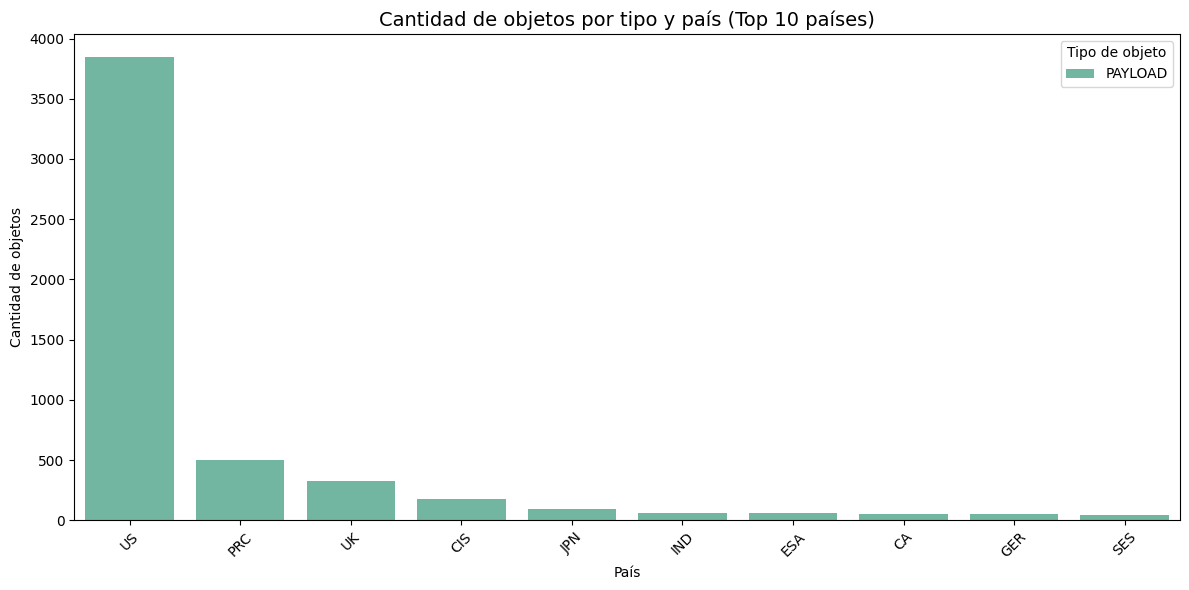

In [ ]:
# Agrupar por país y tipo de objeto
country_type_counts = dataframeUnion.groupby(['COUNTRY', 'OBJECT_TYPE']).size().reset_index(name='count')

# Calcular el total por país
country_totals = country_type_counts.groupby('COUNTRY')['count'].sum().sort_values(ascending=False)

# Filtrar los top N países (opcional)
top_n = 10
top_countries = country_totals.head(top_n).index

# Filtrar el DataFrame original
filtered = country_type_counts[country_type_counts['COUNTRY'].isin(top_countries)]

# Aplicar el orden deseado
filtered['COUNTRY'] = pd.Categorical(filtered['COUNTRY'], categories=top_countries, ordered=True)

# Gráfico ordenado
plt.figure(figsize=(12, 6))
sns.barplot(data=filtered, x='COUNTRY', y='count', hue='OBJECT_TYPE', palette='Set2')

plt.title(f'Cantidad de objetos por tipo y país (Top {top_n} países)', fontsize=14)
plt.xlabel('País')
plt.ylabel('Cantidad de objetos')
plt.xticks(rotation=45)
plt.legend(title='Tipo de objeto')
plt.tight_layout()
plt.show()

In [ ]:
#buscar los paises que tienen mas de 50 objetos en el espacio
paises_mas_50 = dataframe['COUNTRY'].value_counts()[dataframe['COUNTRY'].value_counts() > 50]

/tmp/ipython-input-3297965842.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




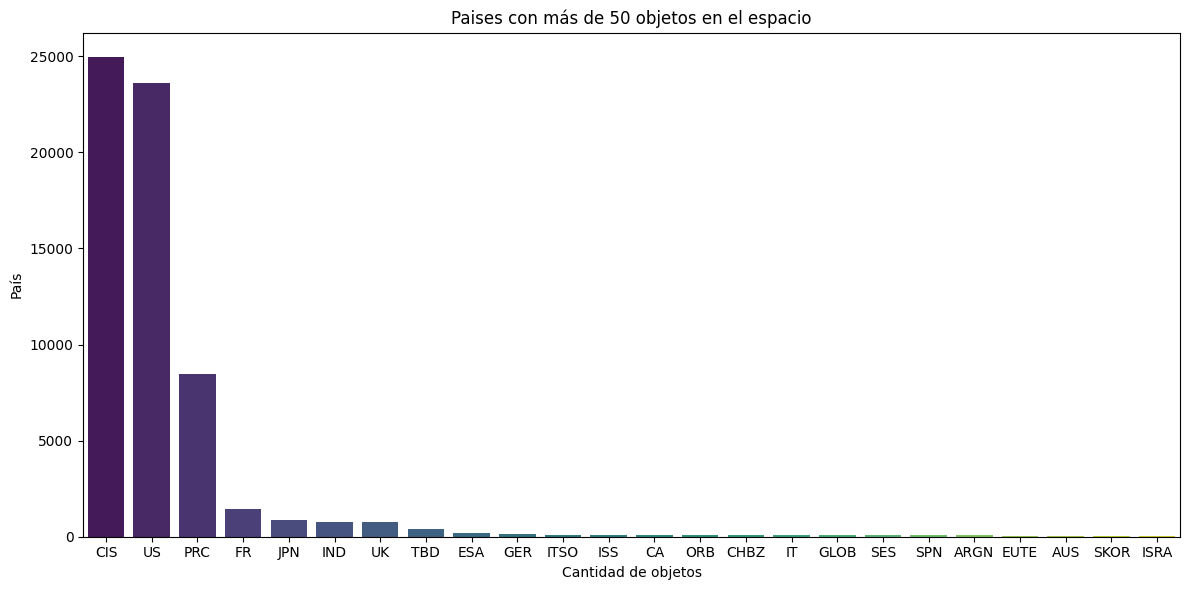

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(y=paises_mas_50.values, x=paises_mas_50.index, orient='vertical',  palette='viridis',)
plt.title('Paises con más de 50 objetos en el espacio')
plt.xlabel('Cantidad de objetos')
plt.ylabel('País')
plt.tight_layout()
plt.show()

El primer gráfico de barras muestra la cantidad de objetos espaciales para los 10 países con mayor cantidad total de objetos. Allí se puede ver que que Estados Unidos (US) es, por un amplio margen, el país con la mayor cantidad de satélites en órbita. En segundo lugar, aunque con una diferencia muy significativa, se encuentra China (PRC), seguida por el Reino Unido (UK) y la Comunidad de Estados Independientes (CIS) (principalmente Rusia).

El segundo gráfico de barras muestra la cantidad total de objetos espaciales para cada país que tiene más de 50 objetos en el espacio.
Allí tenemos que CIS y US tienen más de 25000 objetos en órbita, mientras que PRC aparece en tercer lugar con aproximadamente un tercio de los objetos que tiene US.

Por lo tanto, se puede concluir que la distribución de objetos espaciales está fuertemente concentrada. Rusia/CIS, Estados Unidos y China son responsables de la gran mayoría de objetos en órbita, reflejando su prolongada actividad espacial y el impacto histórico de sus programas.

In [ ]:
# - ¿Cuántos objetos existen según su tipo?
# - ¿Cuál es la relación entre el tamaño del objeto y su tipo de órbita?
# - Comprender el significado de valores nulos: ¿son realmente "faltantes" o tienen un significado particular?
# - ¿Cuáles son las variables que podrían tener mayor influencia en la vida útil o el estado operativo?
# - Determinar la correlación entre variables e identificar patrones
# - ¿Qué porcentaje del dataset contiene datos faltantes? ¿Se pueden imputar?
# - ¿Qué hipótesis se pueden plantear para validar en etapas posteriores?
# - ¿Qué tipo de gráficos aportan más información según la variable a analizar?
# - ¿Se observa una evolución distinta entre diferentes tipos de órbitas?
# - ¿Hay países más propensas a generar desechos?

<Axes: title={'center': 'Cantidad de objetos por tipo'}, xlabel='OBJECT_TYPE'>

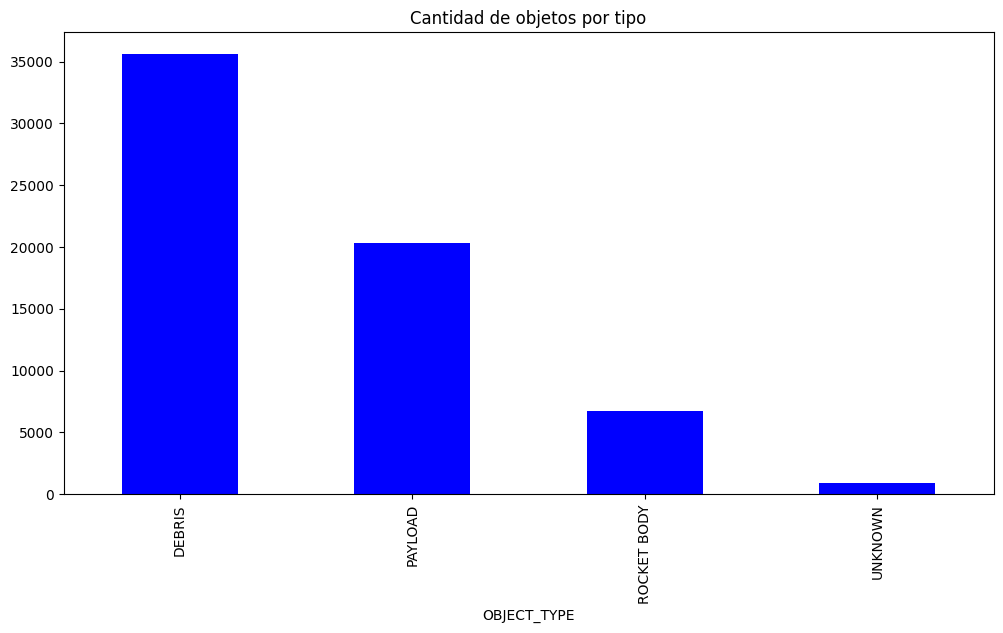

In [ ]:
# - ¿Cuántos objetos existen según su tipo?

dataframe.OBJECT_TYPE.value_counts().plot(kind='bar', figsize=(12, 6), color='blue', title='Cantidad de objetos por tipo')

El gráfico evidencia que la mayoría de los objetos en órbita no son funcionales, sino que pertenecen a la categoría *debris*, es decir,  desechos espaciales. Esto refleja el creciente problema de la basura espacial, que representa riesgos tanto para satélites operativos como para futuras misiones.

En las órbitas tipo GEO tenemos en promedio satelites mas pesados:

In [ ]:
LEO = dataframeUnion[dataframeUnion['Class_of_Orbit'] == 'LEO']['Launch_Mass_kg'].mean()
GEO = dataframeUnion[dataframeUnion['Class_of_Orbit'] == 'GEO']['Launch_Mass_kg'].mean()
MEO = dataframeUnion[dataframeUnion['Class_of_Orbit'] == 'MEO']['Launch_Mass_kg'].mean()

LEO, GEO, MEO

(np.float64(331.8850081532817),
 np.float64(4083.9530685920577),
 np.float64(1250.5140845070423))

Al analizar la expectativa de vida en función del tipo de órbita, tenemos que las tipo GEO tienen en promedio mayor duración:

In [ ]:
expectedLifeLEO = dataframeUnion[dataframeUnion['Class_of_Orbit']
                                 == 'LEO']['Expected_Lifetime_yrs'].mean()
expectedLifeGEO = dataframeUnion[dataframeUnion['Class_of_Orbit']
                                 == 'GEO']['Expected_Lifetime_yrs'].mean()
expectedLifeMEO = dataframeUnion[dataframeUnion['Class_of_Orbit']
                                 == 'MEO']['Expected_Lifetime_yrs'].mean()

expectedLifeLEO, expectedLifeGEO, expectedLifeMEO

(np.float64(4.465279878971256),
 np.float64(13.773833671399593),
 np.float64(9.553719008264462))

Teniendo esto en cuenta, analizamos la distribución de vida útil de objetos en órbitas LEO ya que son los que probablemente mayores desechos generan:

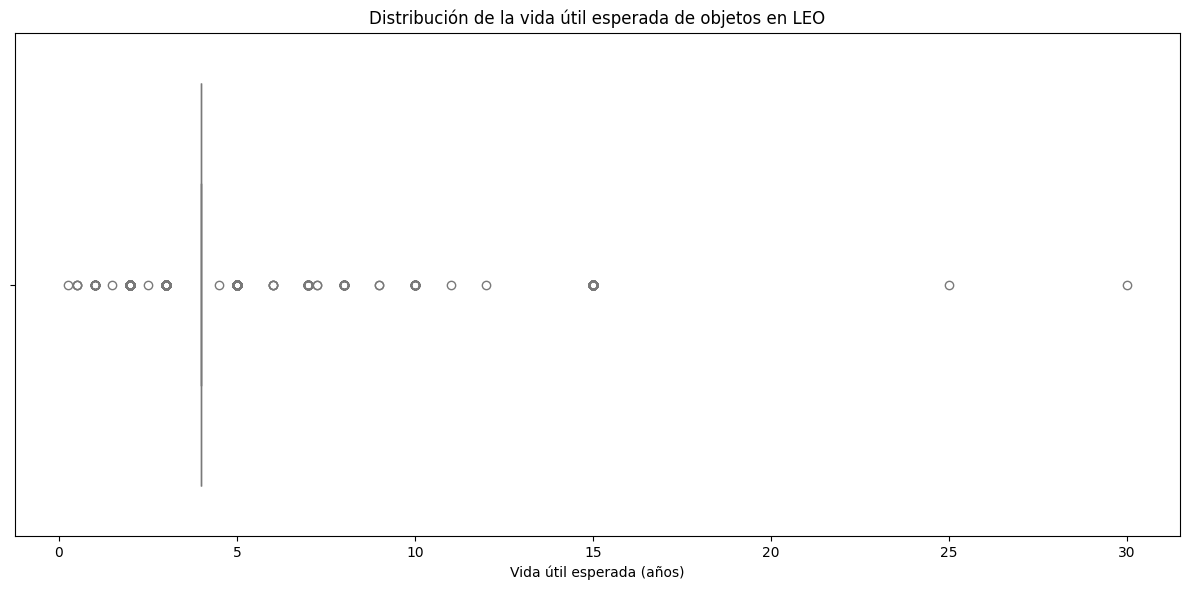

In [ ]:
expectedLifeLEOPlot = dataframeUnion[dataframeUnion['Class_of_Orbit'] == 'LEO']['Expected_Lifetime_yrs'].dropna()
plt.figure(figsize=(12, 6))
sns.boxplot(data=expectedLifeLEOPlot, orient='h', color='lightblue')
plt.title('Distribución de la vida útil esperada de objetos en LEO')
plt.xlabel('Vida útil esperada (años)')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Cantidad de objetos por tipo de órbita'}, xlabel='Class_of_Orbit'>

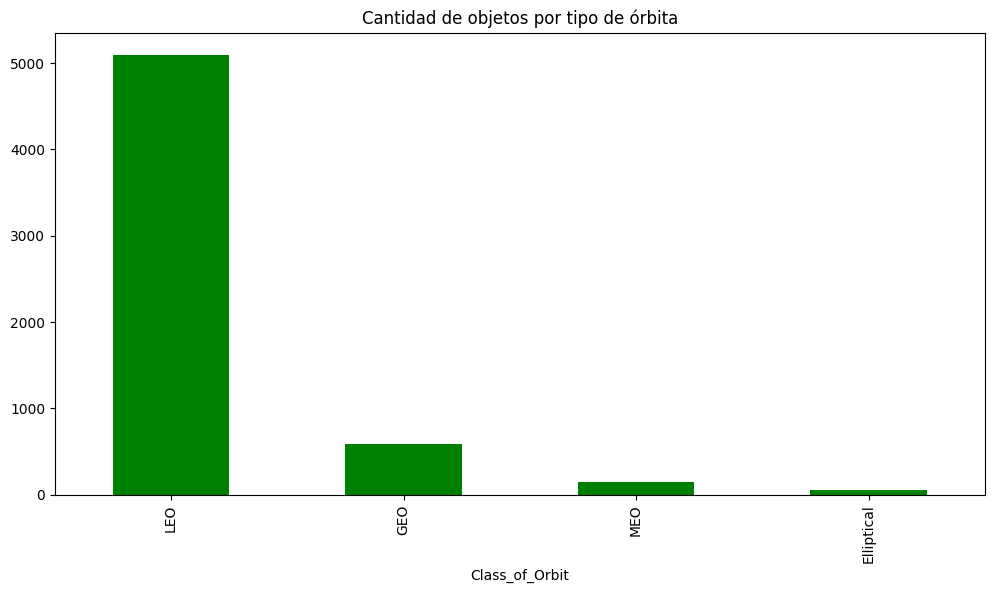

In [ ]:
#mostrar los objetos por tipo de órbita
dataframeUnion['Class_of_Orbit'].value_counts().plot(kind='bar', figsize=(12, 6), color='green', title='Cantidad de objetos por tipo de órbita')


En este gráfico de barras, podemos ver que existen mayor cantidad de objetos en órbitas LEO. Esto tiene sentido, ya que tienen misiones más cortas y costos de reemplazo más bajos.

# Determinar la correlación entre variables e identificar patrones

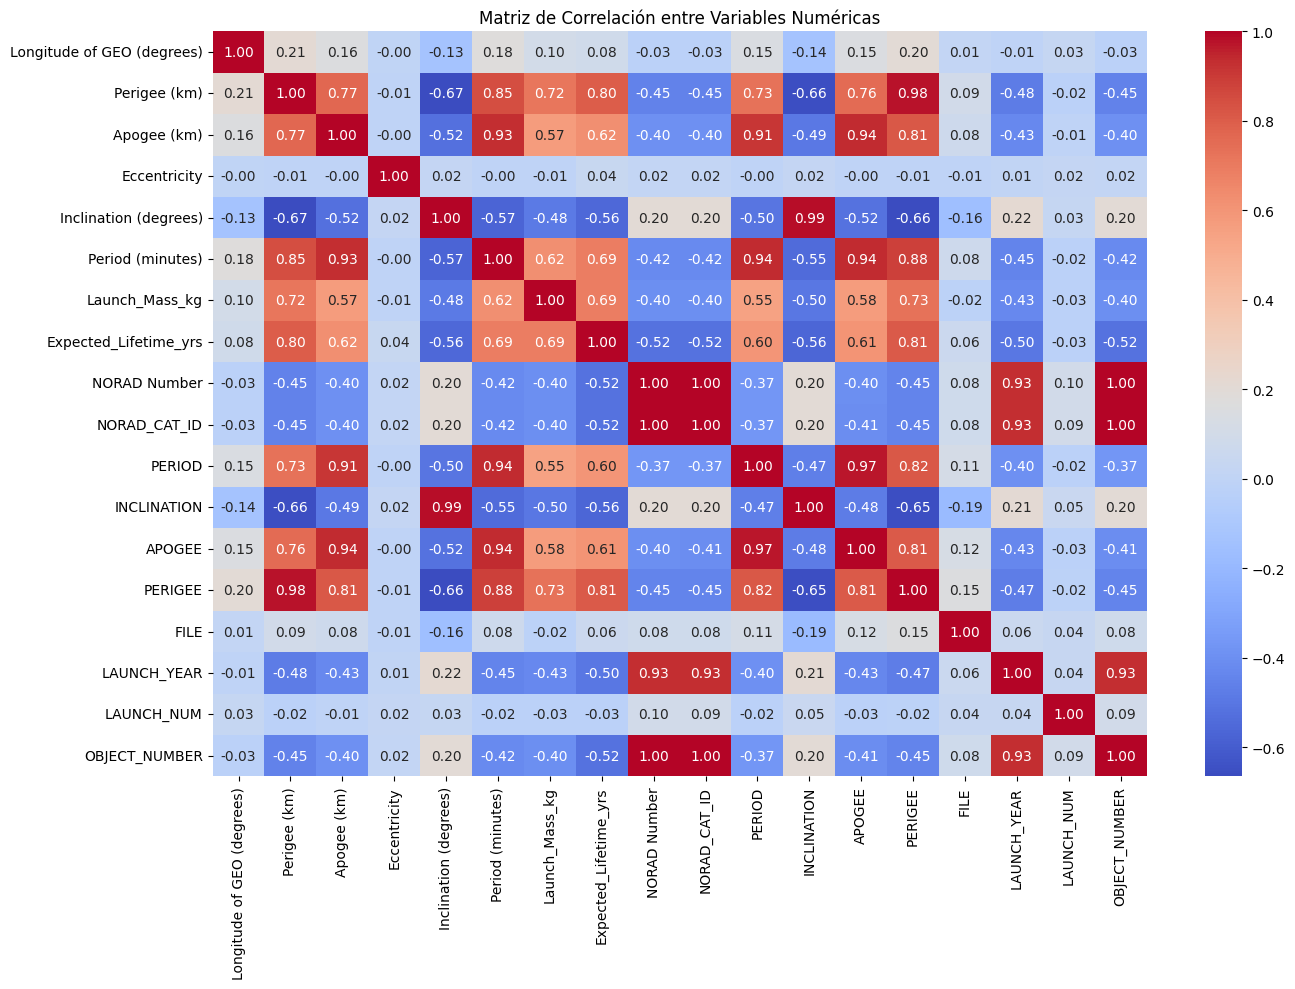

In [ ]:
# Determinar la correlación entre variables numéricas
# Seleccionar solo las columnas numéricas
columnsDrop = ['RCSVALUE','COMMENTCODE']
dataFrameNumerico =  dataframeUnion.select_dtypes(include=['float64', 'int64']).drop(columns=columnsDrop)
# numeric_dataframeUnion = dataframeUnion.select_dtypes(include=['number'])

# Calcular la matriz de correlación
correlation_matrix = dataFrameNumerico.corr()

# Visualizar la matriz de correlación usando un heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación entre Variables Numéricas')
plt.tight_layout()
plt.show()

En la matriz de correlación, se puede apreciar que:

* "Period (minutes)", "Apogee", "Perigee" y "Launch_Mass_kg" tienen correlaciones positivas fuertes entre sí. Esto es consistente con la mecánica orbital: objetos con órbitas más altas suelen tener periodos más largos y muchas veces mayores masas.

* "Expected_Lifetime_yrs" tiene correlación positiva moderada con "Launch_Mass_kg": los satélites más pesados suelen tener mayor vida útil. También se relaciona positivamente con "Apogee" y "Perigee": es decir, los objetos en órbitas más altas tienden a durar más tiempo.

In [ ]:
# Correlación de 'Expected_Lifetime_yrs' con las otras variables numericas
lifetime_correlations = correlation_matrix['Expected_Lifetime_yrs'].sort_values(ascending=False)

# Excluir la correlación de Expected_Lifetime_yrs consigo misma
lifetime_correlations = lifetime_correlations.drop('Expected_Lifetime_yrs')

print("Correlaciones con Expected_Lifetime_yrs:")
print(lifetime_correlations)

Correlaciones con Expected_Lifetime_yrs:
PERIGEE                       0.806099
Perigee (km)                  0.802599
Period (minutes)              0.693342
Launch_Mass_kg                0.688311
Apogee (km)                   0.624954
APOGEE                        0.609135
PERIOD                        0.602050
Longitude of GEO (degrees)    0.084420
FILE                          0.058922
Eccentricity                  0.040671
LAUNCH_NUM                   -0.026988
LAUNCH_YEAR                  -0.497895
NORAD Number                 -0.519927
OBJECT_NUMBER                -0.520366
NORAD_CAT_ID                 -0.520366
Inclination (degrees)        -0.556632
INCLINATION                  -0.562143
Name: Expected_Lifetime_yrs, dtype: float64


# A continuación, analizamos las variables con mayor correlación con "Expected_Lifetime_yrs":

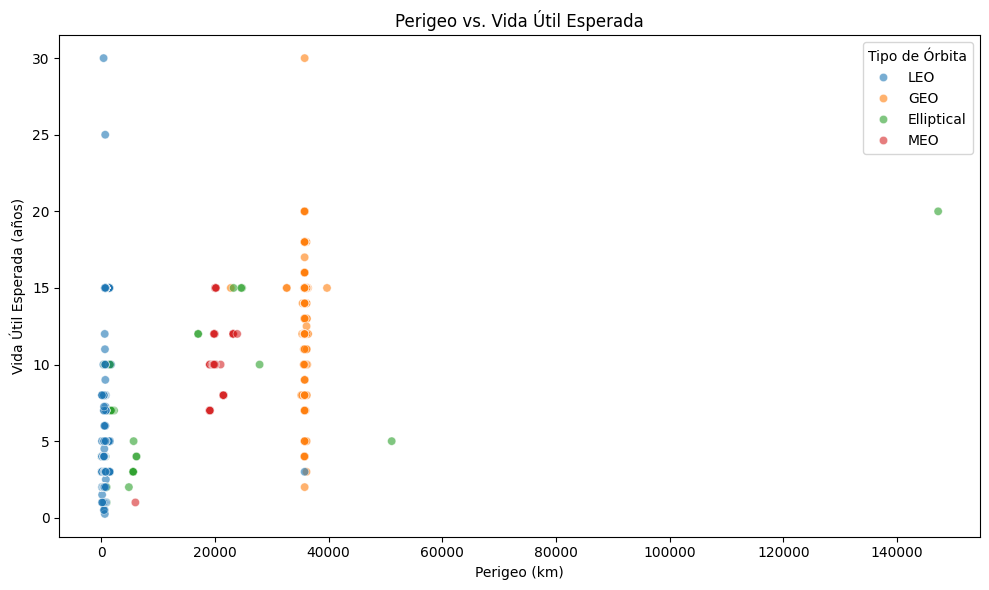

In [ ]:
# grafico de dispersion entre perigeo y expected lifetime

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dataframeUnion,
    x='PERIGEE',
    y='Expected_Lifetime_yrs',
    hue='Class_of_Orbit',   # Categoría de órbita: LEO, MEO, GEO, etc.
    alpha=0.6
)
plt.title('Perigeo vs. Vida Útil Esperada')
plt.xlabel('Perigeo (km)')
plt.ylabel('Vida Útil Esperada (años)')
plt.legend(title='Tipo de Órbita')
plt.tight_layout()
plt.show()

Este gráfico de dispersión muestra la relación entre el Perigeo (la distancia más cercana del objeto a la Tierra en su órbita) y la Vida Útil Esperada del objeto. Podemos ver que:
* Objetos en órbitas con perigeos más bajos (LEO): Tienden a tener una vida útil esperada más corta.
* Objetos en órbitas con perigeos más altos (MEO y GEO): Tienden a tener una vida útil esperada significativamente mayor.

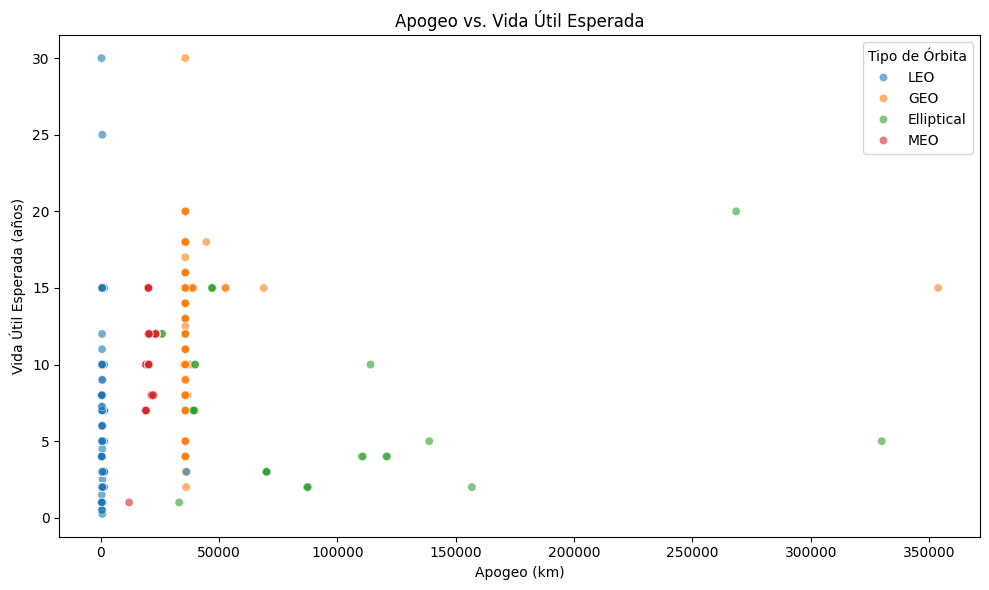

In [ ]:
# grafico de dispersion entre apogeo y expected lifetime

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dataframeUnion,
    x='Apogee (km)',
    y='Expected_Lifetime_yrs',
    hue='Class_of_Orbit',   # Categoría de órbita: LEO, MEO, GEO, etc.
    alpha=0.6
)
plt.title('Apogeo vs. Vida Útil Esperada')
plt.xlabel('Apogeo (km)')
plt.ylabel('Vida Útil Esperada (años)')
plt.legend(title='Tipo de Órbita')
plt.tight_layout()
plt.show()

Este gráfico de dispersión muestra la relación entre el Apogeo (la distancia más lejana del objeto a la Tierra en su órbita) y la Vida Útil Esperada del objeto. Nuevamente, podemos ver que:
* Objetos en órbitas con perigeos más bajos (LEO): Tienden a tener una vida útil esperada más corta.
* Objetos en órbitas con perigeos más altos (MEO y GEO):** Tienden a tener una vida útil esperada significativamente mayor.

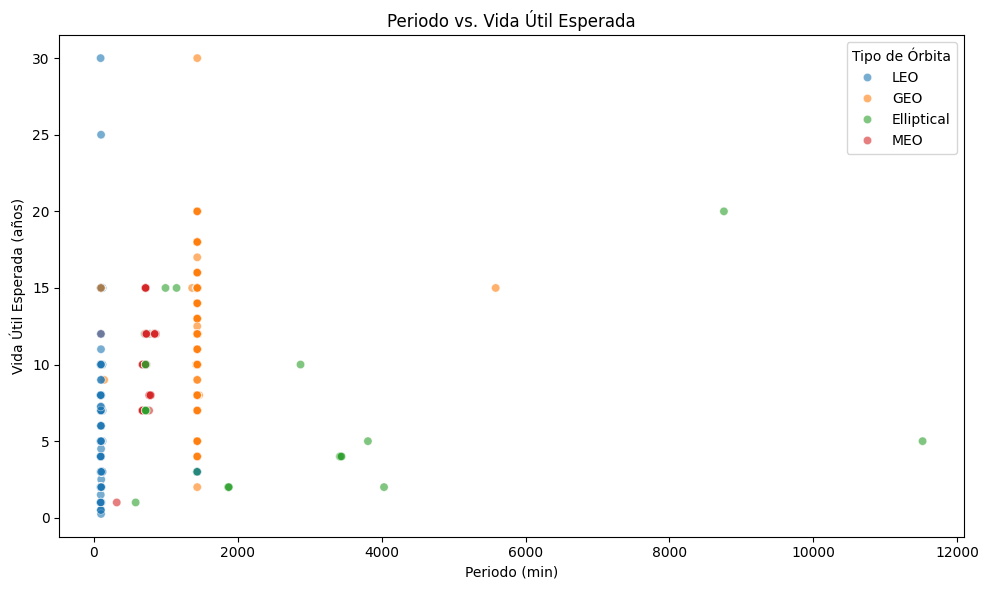

In [ ]:
# grafico de dispersion entre periodo y expected lifetime

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dataframeUnion,
    x='Period (minutes)',
    y='Expected_Lifetime_yrs',
    hue='Class_of_Orbit',   # Categoría de órbita: LEO, MEO, GEO, etc.
    alpha=0.6
)
plt.title('Periodo vs. Vida Útil Esperada')
plt.xlabel('Periodo (min)')
plt.ylabel('Vida Útil Esperada (años)')
plt.legend(title='Tipo de Órbita')
plt.tight_layout()
plt.show()

Este gráfico de dispersión muestra la relación entre el Período Orbital (el tiempo que tarda un objeto en completar una órbita alrededor de la Tierra) y la Vida Útil Esperada del objeto. Al igual que en los gráficos anteriores, se observa una clara relación:

*   Órbitas LEO: Tienden a tener una vida útil esperada más corta.
*   Órbitas MEO y GEO: Tienden a tener una vida útil esperada significativamente mayor.

En resumen, los tres gráficos de dispersión (Perigeo vs. Vida Útil, Apogeo vs. Vida Útil y Período vs. Vida Útil) refuerzan la misma conclusión: **las órbitas más altas (con perigeos, apogeos y períodos mayores) están fuertemente asociadas con una vida útil esperada más larga de los objetos espaciales.**

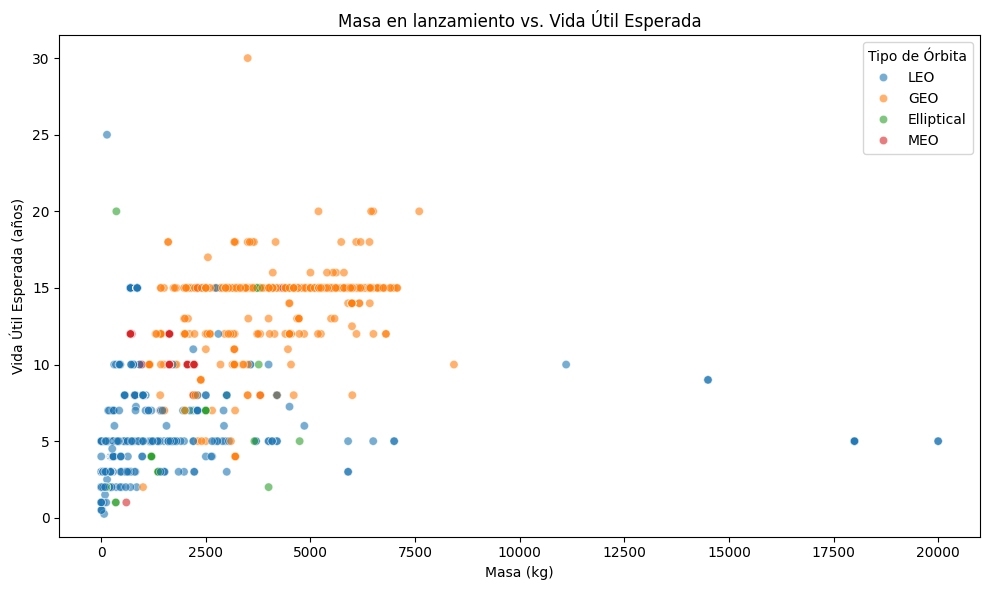

In [ ]:
# grafico de dispersion entre Launch_Mass_kg y expected lifetime

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=dataframeUnion,
    x='Launch_Mass_kg',
    y='Expected_Lifetime_yrs',
    hue='Class_of_Orbit',   # Categoría de órbita: LEO, MEO, GEO, etc.
    alpha=0.6
)
plt.title('Masa en lanzamiento vs. Vida Útil Esperada')
plt.xlabel('Masa (kg)')
plt.ylabel('Vida Útil Esperada (años)')
plt.legend(title='Tipo de Órbita')
plt.tight_layout()
plt.show()

Este gráfico de dispersión muestra la relación entre la masa del objeto en el momento del lanzamiento ('Launch_Mass_kg') y su vida útil esperada ('Expected_Lifetime_yrs').

Aunque no es una correlación lineal perfecta, hay una tendencia a que los objetos con mayor masa en el lanzamiento tiendan a tener una vida útil esperada más larga, especialmente dentro de ciertas clases de órbita (GEO y MEO).

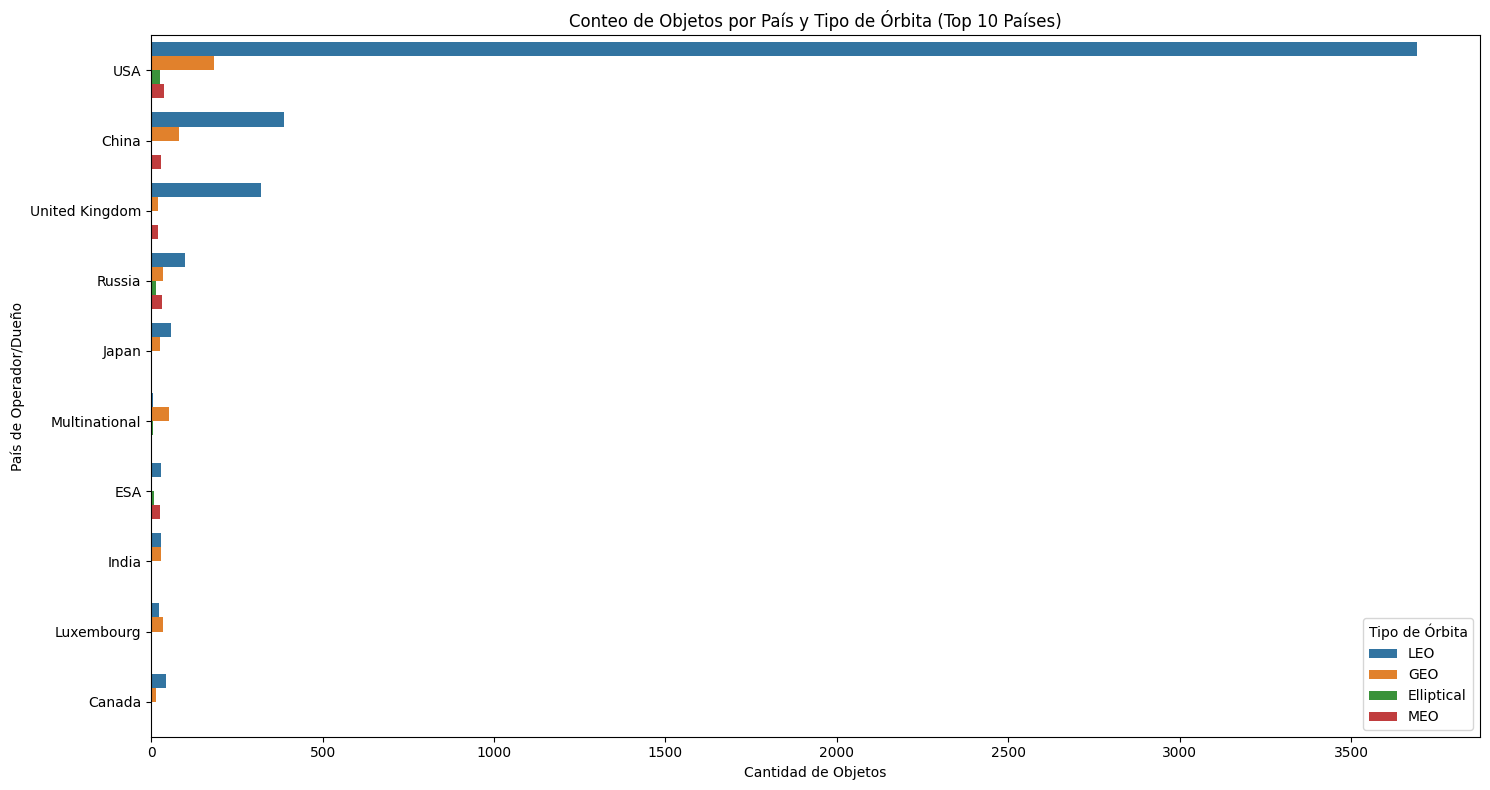

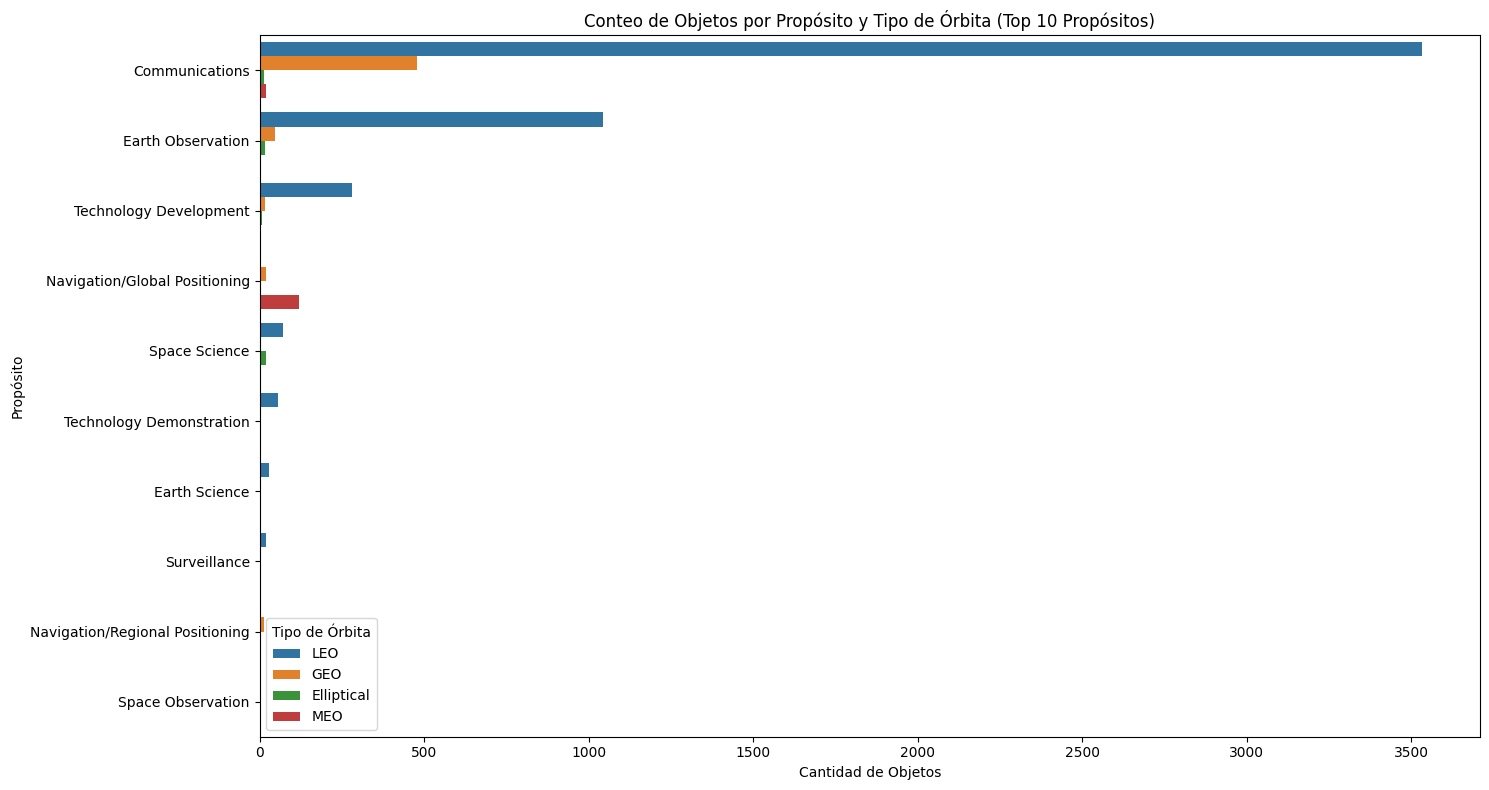

In [ ]:
# Identificar posibles patrones en variables categóricas
# Relación entre País y Tipo de Órbita
plt.figure(figsize=(15, 8))
sns.countplot(data=dataframeUnion, y='Country_of_Operator_Owner', hue='Class_of_Orbit', order=dataframeUnion['Country_of_Operator_Owner'].value_counts().index[:10], palette='tab10')
plt.title('Conteo de Objetos por País y Tipo de Órbita (Top 10 Países)')
plt.xlabel('Cantidad de Objetos')
plt.ylabel('País de Operador/Dueño')
plt.legend(title='Tipo de Órbita')
plt.tight_layout()
plt.show()

# Relación entre Propósito y Tipo de Órbita
plt.figure(figsize=(15, 8))
sns.countplot(data=dataframeUnion, y='Purpose', hue='Class_of_Orbit', order=dataframeUnion['Purpose'].value_counts().index[:10], palette='tab10')
plt.title('Conteo de Objetos por Propósito y Tipo de Órbita (Top 10 Propósitos)')
plt.xlabel('Cantidad de Objetos')
plt.ylabel('Propósito')
plt.legend(title='Tipo de Órbita')
plt.tight_layout()
plt.show()

El primer gráfico de barras muestra la cantidad de objetos espaciales correspondientes a los 10 países con mayor número total de objetos en órbita. Las barras están segmentadas según el tipo de órbita, lo que permite visualizar cómo se distribuyen estos objetos dentro de cada país. Se observa claramente que Estados Unidos (US) lidera en cantidad de satélites en órbitas LEO, seguido por China (PRC), el Reino Unido (UK) y la Comunidad de Estados Independientes (CIS).

El segundo gráfico de barras presenta la cantidad de objetos espaciales asociados a los 10 propósitos más frecuentes. Al igual que en el gráfico anterior, las barras están desagregadas por tipo de órbita, lo que permite analizar cómo se distribuyen los distintos propósitos en las diferentes órbitas. Se destaca que los satélites destinados a comunicaciones, observación de la Tierra y desarrollo tecnológico son los más numerosos, especialmente en órbitas LEO.

/tmp/ipython-input-3232714366.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




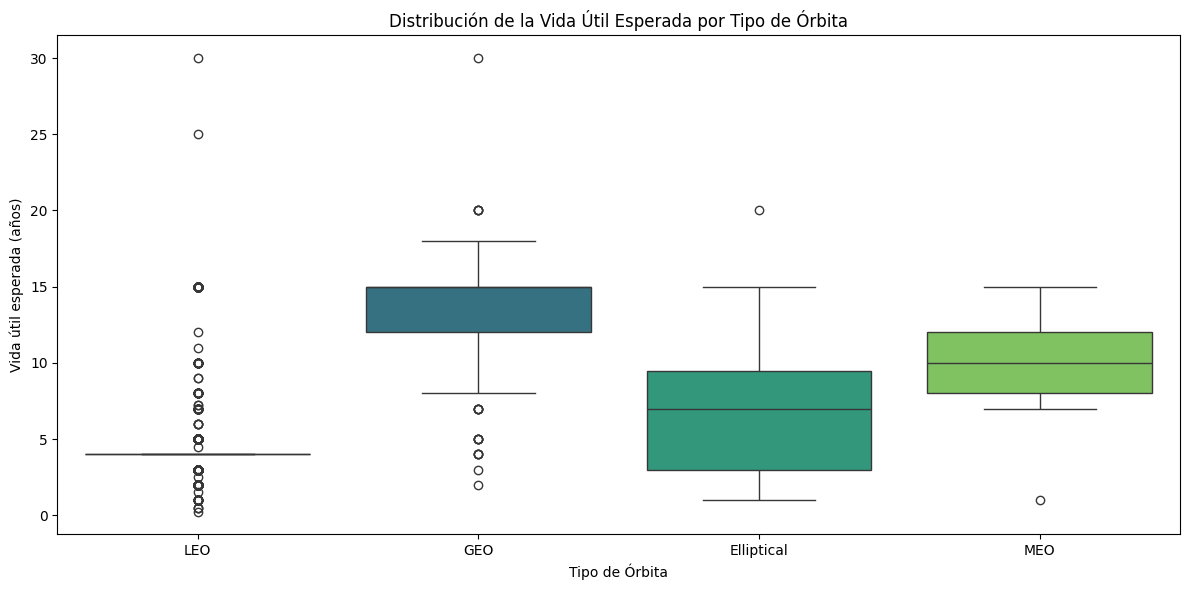

In [ ]:
# Relación entre el tipo de objeto y la vida útil esperada
plt.figure(figsize=(12, 6))
sns.boxplot(data=dataframeUnion, x='Class_of_Orbit', y='Expected_Lifetime_yrs', palette='viridis')
plt.title('Distribución de la Vida Útil Esperada por Tipo de Órbita')
plt.xlabel('Tipo de Órbita')
plt.ylabel('Vida útil esperada (años)')
plt.tight_layout()
plt.show()

Al analizar la distribución de la vida útil esperada para cada tipo de órbita, tenemos que las órbitas más altas (GEO, MEO) tienen medianas y rangos intercuartílicos de vida útil esperada más altos que las órbitas LEO, confirmando las observaciones de los gráficos de dispersión anteriores.

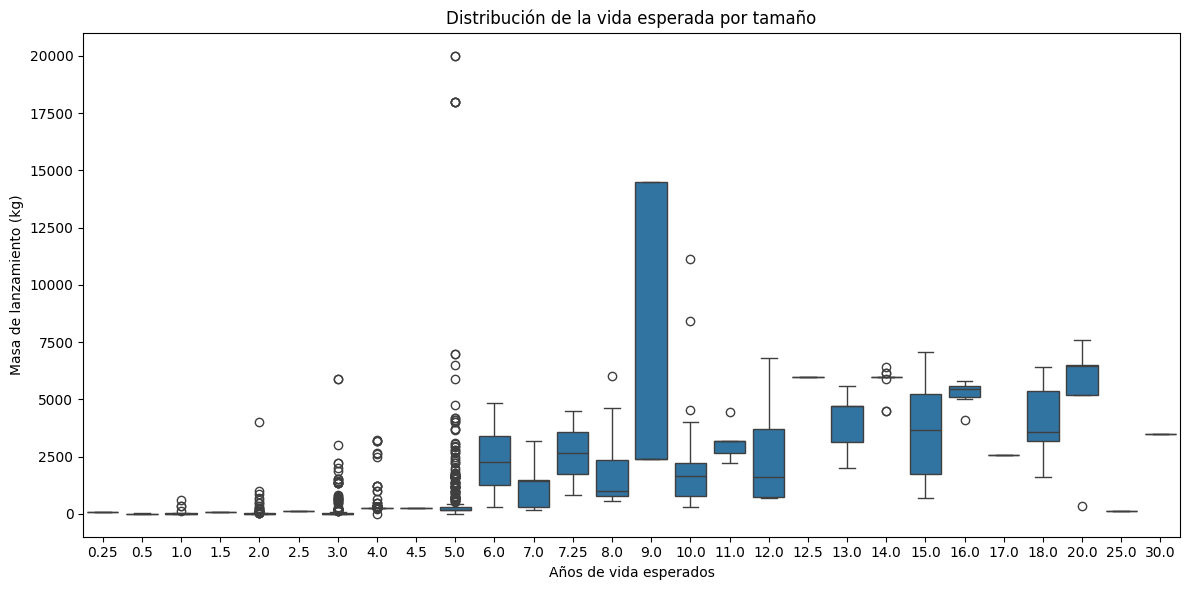

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=dataframeUnion, x='Expected_Lifetime_yrs', y='Launch_Mass_kg')
plt.title('Distribución de la vida esperada por tamaño')
plt.xlabel('Años de vida esperados')
plt.ylabel('Masa de lanzamiento (kg)')
plt.tight_layout()
plt.show()

# ¿Qué porcentaje del dataset contiene datos faltantes? ¿Se pueden imputar?

In [ ]:
# Porcentaje de valores faltantes del dataframeUnion
missing_data_percentage = (dataframeUnion.isnull().sum() / len(dataframeUnion)) * 100

# Display the columns with missing data and their percentages
print("Porcentaje de datos faltantes por columna:")
print(missing_data_percentage[missing_data_percentage > 0].sort_values(ascending=False))

Porcentaje de datos faltantes por columna:
COMMENTCODE                   99.779137
COMMENT                       99.371390
Power (watts)                 90.163099
Dry Mass (kg.)                87.597689
Detailed Purpose              80.971797
DECAY                         77.845736
Expected_Lifetime_yrs         32.840639
Type_of_Orbit                 11.043153
Launch_Mass_kg                 3.941556
RCS_SIZE                       2.276589
Period (minutes)               0.883452
APOGEE                         0.730547
PERIOD                         0.730547
INCLINATION                    0.730547
PERIGEE                        0.730547
Eccentricity                   0.118926
Longitude of GEO (degrees)     0.050968
Perigee (km)                   0.050968
Inclination (degrees)          0.050968
Apogee (km)                    0.050968
Country/Org of UN Registry     0.016989
Date of Launch                 0.016989
dtype: float64


Teniendo en cuenta los porcentajes de datos faltantes, consideramos que aquellas variables con más del 70% de valores ausentes no justifican su imputación, ya que el resultado sería altamente sintético o artificial, lo cual comprometería la fiabilidad del análisis posterior. En consecuencia, estas variables serán descartadas.

En particular, la variable decay, a pesar de presentar un alto porcentaje de datos faltantes, no será descartada. Esto se debe a que su ausencia podría no deberse a errores de registro, sino a una causa estructural: la falta de este dato puede indicar que el satélite aún no ha reentrado en la atmósfera y, por lo tanto, no ha finalizado su vida útil.

Por otro lado, aunque las demás variables también presentan cierto grado de datos faltantes, se considera que contienen información relevante para determinar la vida útil
de los satelites


# ¿Qué hipótesis se pueden plantear para validar en etapas posteriores?

Teniendo en cuenta lo visto en los datos, se puede estimar que:
* Los países con más objetos espaciales tienen una mayor proporción de desechos.
* Los objetos situados en órbita GEO tienen una vida útil más larga que los situados en órbita LEO y MEO.
* La finalidad de un objeto está relacionada con su vida útil prevista.
* Existe una correlación entre la masa de lanzamiento y la vida útil prevista.

# ¿Se observa una evolución distinta entre diferentes tipos de órbitas?

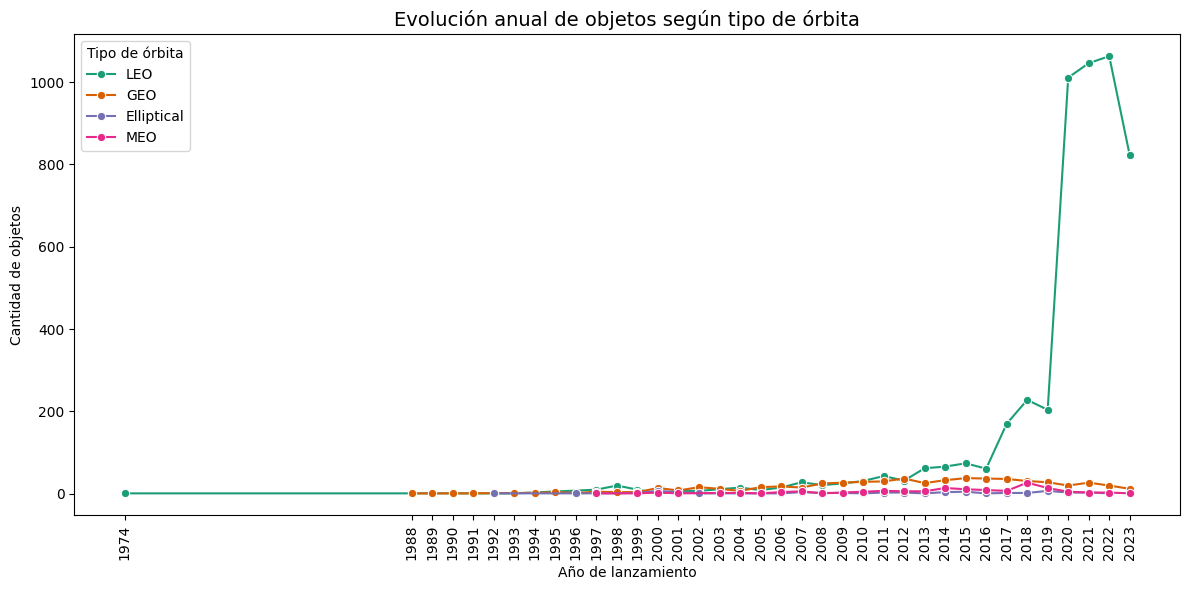

In [ ]:
# Agrupar por año y tipo de órbita
year_orbit_counts = dataframeUnion.groupby(['LAUNCH_YEAR', 'Class_of_Orbit']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=year_orbit_counts, x='LAUNCH_YEAR', y='count', hue='Class_of_Orbit', marker='o', palette='Dark2')

# Mostrar un tick por cada año
years = sorted(dataframeUnion['LAUNCH_YEAR'].dropna().unique())
plt.xticks(ticks=years, rotation=90)

plt.title('Evolución anual de objetos según tipo de órbita', fontsize=14)
plt.xlabel('Año de lanzamiento')
plt.ylabel('Cantidad de objetos')
plt.legend(title='Tipo de órbita')
plt.tight_layout()
plt.show()

Al analizar la evolución anual de la cantidad de objetos lanzados al espacio, segmentados por el tipo de órbita (LEO, MEO, GEO), se observa una tendencia general de aumento en la cantidad de objetos lanzados a lo largo de los años, con un pico notable en los años más recientes, particularmente para las órbitas LEO. Las órbitas GEO y MEO muestran un crecimiento más estable y menos pronunciado en comparación con las órbitas LEO.

Este gráfico sugiere que la actividad espacial ha aumentado significativamente en las últimas décadas, y que las órbitas bajas (LEO) son actualmente las más utilizadas para el lanzamiento de nuevos objetos.

# ¿Hay países más propensas a generar desechos?

/tmp/ipython-input-1333102329.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




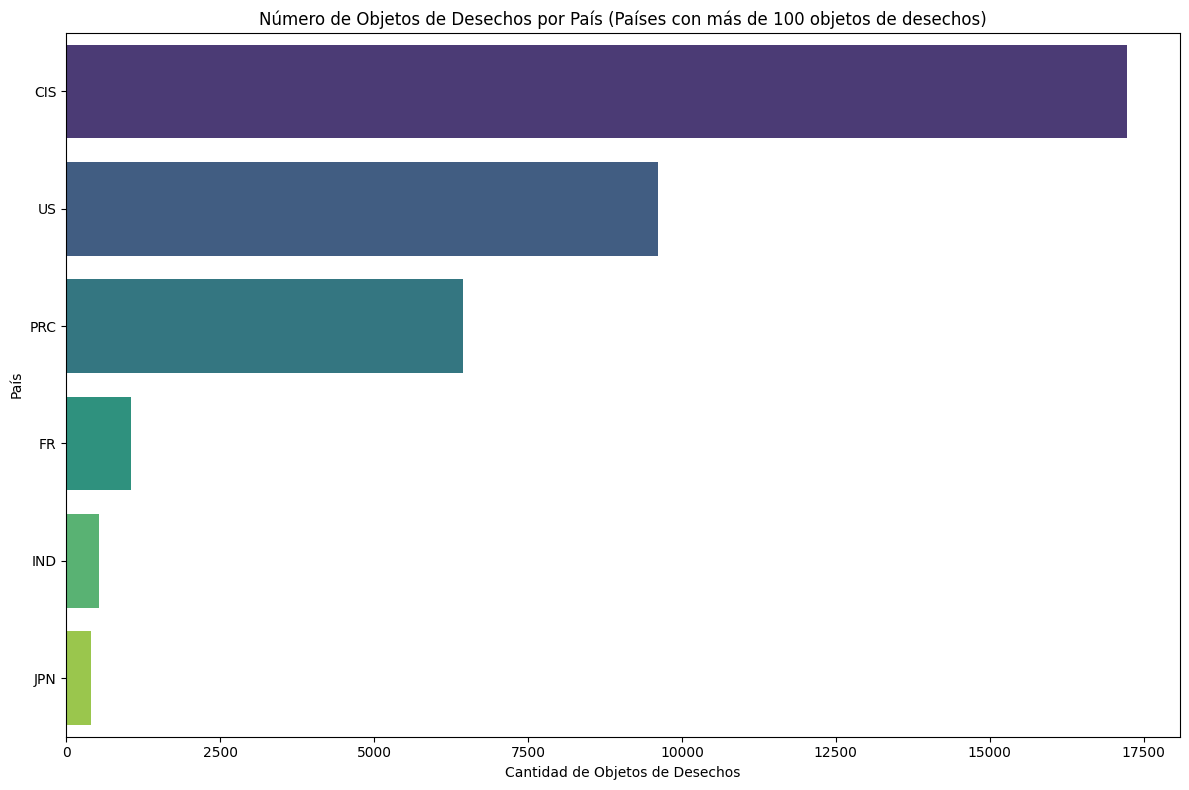

In [ ]:
# tomamos solo los objetos 'DEBRIS' del dataframe
debris_df = dataframe[dataframe['OBJECT_TYPE'] == 'DEBRIS']

# Contamos el numero de objetos debris por pais
debris_by_country = debris_df['COUNTRY'].value_counts()

# Seleccionamos países con un número significativo de restos (pmás de 100) para una mejor visualización.
debris_by_country_filtered = debris_by_country[debris_by_country > 100]

# Graficamos
plt.figure(figsize=(12, 8))
sns.barplot(y=debris_by_country_filtered.index, x=debris_by_country_filtered.values, palette='viridis')
plt.title('Número de Objetos de Desechos por País (Países con más de 100 objetos de desechos)')
plt.xlabel('Cantidad de Objetos de Desechos')
plt.ylabel('País')
plt.tight_layout()
plt.show()

Este gráfico se centra específicamente en el problema de los desechos espaciales (es decir, aquellos clasificados como *debris*) y permite identificar qué países son los principales contribuidores a la basura espacial en órbita.  Al observar los datos, se destaca que CIS, US y PRC son los principales paises  generadores de desechos espaciales.

### ¿Cuáles son las variables que podrían tener mayor influencia en la vida útil o el estado operativo?

1. launch (fecha de lanzamiento)  
    Motivo: A mayor antigüedad, mayor probabilidad de estar inactivo o desintegrado.

2. decay (fecha de desintegración o caída)  
    Motivo: Indica que el objeto ya no está en órbita. Si es NaN, probablemente sigue activo.
3. rcs_size (tamaño estimado del objeto), Launch_Mass_kg (masa en el momento del lanzamiento):
    Objetos muy pequeños y con poca masa (DEBRIS) suelen tener vida útil nula. Satélites grandes y pesados tienden a durar más.
4. period, inclination, apogee, perigee  
    Órbitas bajas (LEO) tienden a sufrir más fricción atmosférica → vida útil más corta.
    Las órbitas altas (GEO) pueden durar décadas.
5. launch_site / country  
    Algunos países o sitios lanzan satélites de mayor calidad o más duraderos.
6. purpose (proposito):
    El proposito del satelite también determina la duración del mismo.



---


# **Práctico 2 - Análisis Exploratorio y Curación de Datos**

Sugerencias para el análisis:

* El tipo de dato a utilizar (o convertir) en las variables int, float, datetime, etc.
* ¿Es .json la mejor forma de guardar los datos?
Teniendo en cuenta que el formato .json no es eficiente para grandes volúmenes de datos (mucho texto repetido), y tampoco es el mejor formato para análisis en pandas, entonces podemos concluir que no es el mejor formato para guardar los datos.
* Según los datos ¿Conviene usar StandardScaler, MinMaxScaler u otro método para escalar?
* ¿Cuando utilizar OneHotEncoder, OrdinalEncoder y/o LabelEncoder para las variables categóricas?
* Elegir y comparar el mejor método de imputación según los datos faltantes.
* Determinar como van a separar los datos en entrenamiento, evaluación y test.
* Comparar los datos antes y despues de realizar EDA.

# En primer lugar, agrupamos las categorias de la variable 'purpose' de la siguiente manera:

In [ ]:
# Limpia los strings antes de comparar
dataframeUnion['Purpose'] = dataframeUnion['Purpose'].str.strip()

# Definir las listas para cada grupo
communications_categories = [
    'Communications',
    'Navigation/Global Positioning',
    'Surveillance',
    'Communications/Maritime Tracking',
    'Communications/Technology Development',
    'Communications/Navigation',
    'Satellite Positioning'
]

earth_observation_categories = [
    'Earth Observation',
    'Earth Science',
    'Earth Observation/Navigation',
    'Earth/Space Observation',
    'Earth Observation/Communications',
    'Earth Observation/Communications/Space Science',
    'Earth Science/Earth Observation',
    'Earth Observation/Space Science',
    'Earth Observation/Earth Science'
]

technology_development_categories = [
    'Technology Development',
    'Space Science',
    'Technology Demonstration',
    'Unknown',
    'Space Observation',
    'Earth Observation/Technology Development',
    'Meteorological',
    'Mission Extension Technology',
    'Technology Development/Educational',
    'Space Science/Technology Development',
    'Educational',
    'Platform',
    'Space Science/Technology Demonstration'
]

# Función para asignar el grupo correspondiente
def group_purpose(purpose):
    if purpose in communications_categories:
        return 'Communications'
    elif purpose in earth_observation_categories:
        return 'Earth Observation'
    elif purpose in technology_development_categories:
        return 'Technology Development'
    else:
        return purpose  # deja el valor original si no está en ninguna lista

# Aplicar la función
dataframeUnion['Purpose_Grouped'] = dataframeUnion['Purpose'].apply(group_purpose)

# Verificar el resultado
dataframeUnion['Purpose_Grouped'].value_counts()

,count
Purpose_Grouped,
Communications,4219
Earth Observation,1161
Technology Development,493
Navigation/Regional Positioning,13


In [ ]:
dataframeUnion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5886 entries, 0 to 5885
Data columns (total 52 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Name of Satellite, Alternate Names  5886 non-null   object 
 1   Current Official Name of Satellite  5886 non-null   object 
 2   Country/Org of UN Registry          5885 non-null   object 
 3   Country_of_Operator_Owner           5886 non-null   object 
 4   Operator/Owner                      5886 non-null   object 
 5   Users                               5886 non-null   object 
 6   Purpose                             5886 non-null   object 
 7   Detailed Purpose                    1120 non-null   object 
 8   Class_of_Orbit                      5886 non-null   object 
 9   Type_of_Orbit                       5236 non-null   object 
 10  Longitude of GEO (degrees)          5883 non-null   float64
 11  Perigee (km)                        5883 no

Teniendo en cuenta que las variables 'Detailed Purpose', 'dry mass', 'power', 'comment' y 'commentcode' tienen muy pocos datos y por lo tanto no justifican su imputación, ya que el resultado sería altamente ficticio, las quitamos.
Tambien eliminamos la columna 'Purpose' y nos quedamos con la columna con datos agrupados del paso anterior.

In [ ]:
# eliminar las columnas Detailed Purpose, dry mass, power, comment y commentcode

dataframe = dataframeUnion.drop(columns=['Purpose','Detailed Purpose', 'Dry Mass (kg.)', 'Power (watts)', 'COMMENT', 'COMMENTCODE'], errors='ignore')
dataframeUnion.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5886 entries, 0 to 5885
Data columns (total 52 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Name of Satellite, Alternate Names  5886 non-null   object 
 1   Current Official Name of Satellite  5886 non-null   object 
 2   Country/Org of UN Registry          5885 non-null   object 
 3   Country_of_Operator_Owner           5886 non-null   object 
 4   Operator/Owner                      5886 non-null   object 
 5   Users                               5886 non-null   object 
 6   Purpose                             5886 non-null   object 
 7   Detailed Purpose                    1120 non-null   object 
 8   Class_of_Orbit                      5886 non-null   object 
 9   Type_of_Orbit                       5236 non-null   object 
 10  Longitude of GEO (degrees)          5883 non-null   float64
 11  Perigee (km)                        5883 no

A continuación, analizamos las columnas que parecieran repetirse: Apogeo, Perigeo, Inclinación y Período.

Correlación entre 'APOGEE' y 'Apogee (km)': 0.9377803088613519
Correlación entre 'PERIGEE' y 'Perigee (km)': 0.9782740407233774
Correlación entre 'INCLINATION' e 'Inclination (degrees)': 0.9853046393801599
Correlación entre 'PERIOD' y 'Period (minutes)': 0.9374295397268965


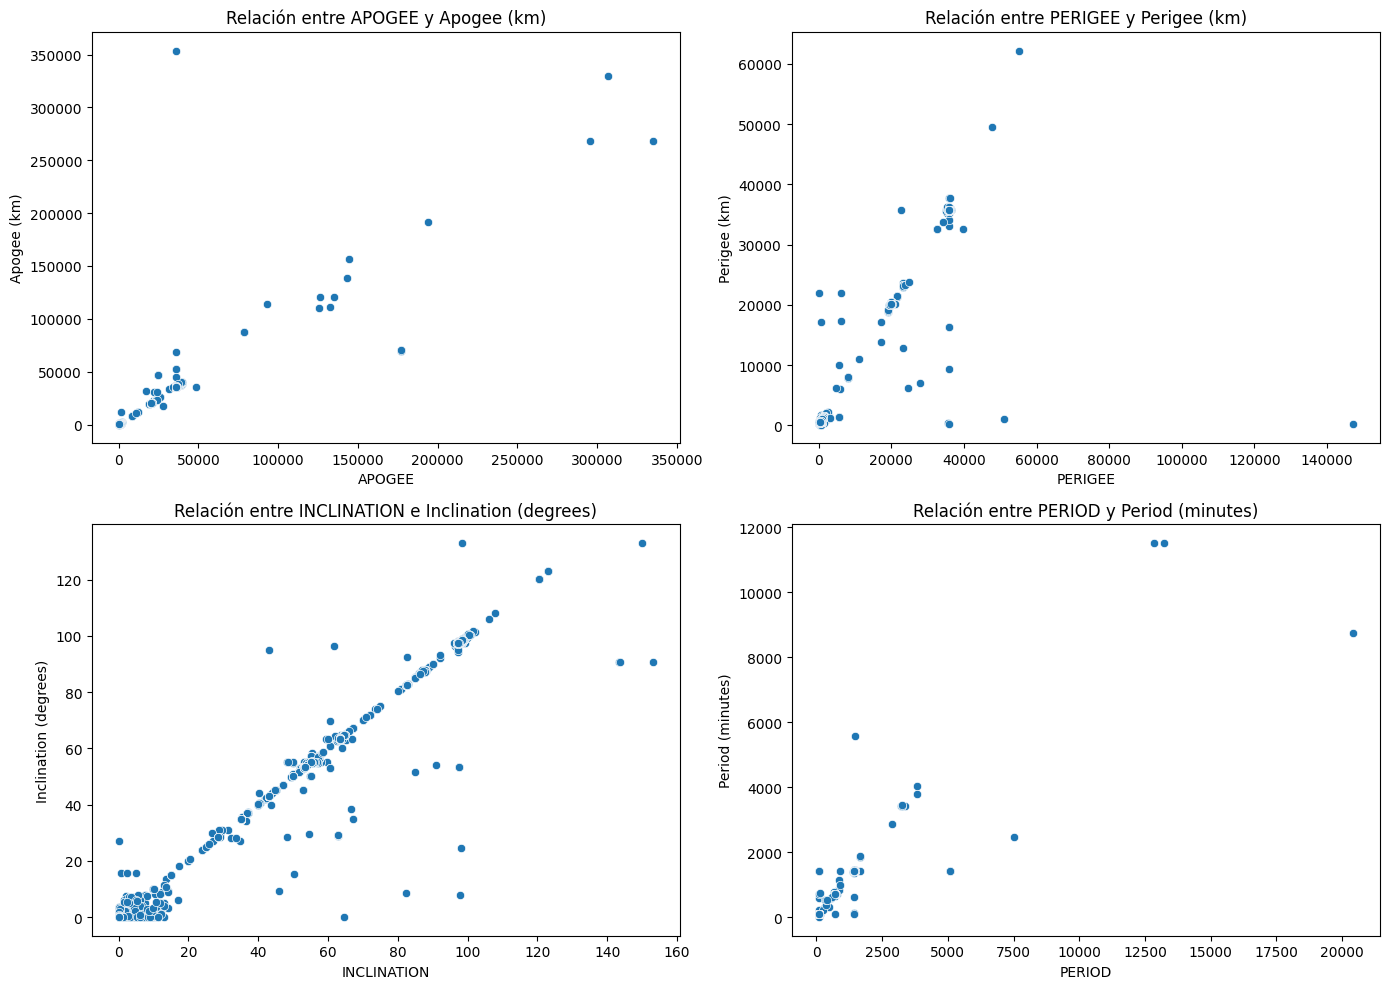

In [ ]:
# Verificar la correlación entre 'APOGEE' y 'Apogee (km)'
correlacion_apogeo = dataframeUnion['APOGEE'].corr(dataframeUnion['Apogee (km)'])
print(f"Correlación entre 'APOGEE' y 'Apogee (km)': {correlacion_apogeo}")

# Verificar la correlación entre PERIGEE y Perigee (km)
correlacion_perigeo = dataframeUnion['PERIGEE'].corr(dataframeUnion['Perigee (km)'])
print(f"Correlación entre 'PERIGEE' y 'Perigee (km)': {correlacion_perigeo}")

# Verificar la correlación entre 'INCLINATION' e 'Inclination (degrees)'
correlacion_inclinacion = dataframeUnion['INCLINATION'].corr(dataframeUnion['Inclination (degrees)'])
print(f"Correlación entre 'INCLINATION' e 'Inclination (degrees)': {correlacion_inclinacion}")

# Verificar la correlación entre 'PERIOD' y 'Period (minutes)'
correlacion_periodo = dataframeUnion['PERIOD'].corr(dataframeUnion['Period (minutes)'])
print(f"Correlación entre 'PERIOD' y 'Period (minutes)': {correlacion_periodo}")


# Visualizar las relaciones con un scatter plot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: relación entre 'APOGEE' y 'Apogee (km)'
sns.scatterplot(
    data=dataframeUnion,
    x='APOGEE',
    y='Apogee (km)',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Relación entre APOGEE y Apogee (km)')
axes[0, 0].set_xlabel('APOGEE')
axes[0, 0].set_ylabel('Apogee (km)')
#axes[0, 0].legend(title='Tipo de Órbita')

#plot 2: relación entre 'PERIGEE' y 'Perigee (km)'
sns.scatterplot(
    data=dataframeUnion,
    x='PERIGEE',
    y='Perigee (km)',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Relación entre PERIGEE y Perigee (km)')
axes[0, 1].set_xlabel('PERIGEE')
axes[0, 1].set_ylabel('Perigee (km)')

#plot 3: relación entre 'INCLINATION' e 'Inclination (degrees)'
sns.scatterplot(
    data=dataframeUnion,
    x='INCLINATION',
    y='Inclination (degrees)',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Relación entre INCLINATION e Inclination (degrees)')
axes[1, 0].set_xlabel('INCLINATION')
axes[1, 0].set_ylabel('Inclination (degrees)')

# plot 4: relación entre 'PERIOD' y 'Period (minutes)'
sns.scatterplot(
    data=dataframeUnion,
    x='PERIOD',
    y='Period (minutes)',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Relación entre PERIOD y Period (minutes)')
axes[1, 1].set_xlabel('PERIOD')
axes[1, 1].set_ylabel('Period (minutes)')

plt.tight_layout()
plt.show()

El análisis de los gráficos de dispersión muestra que existe una relación lineal entre los pares de columnas: APOGEE y Apogee (km), PERIGEE y Perigeo (km), INCLINATION e Inclination (degrees), PERIOD y Period (minutes). La alta correlación numérica calculada previamente confirma esta observación. Esto nos indica que se trata del mismo dato. Para elegir con cuál nos quedamos, analizamos aquellos que tienen menor cantidad de datos faltantes.

In [ ]:
# Calculate missing values percentage for the relevant columns
missing_percentage_pairs = dataframeUnion[['APOGEE', 'Apogee (km)', 'PERIGEE', 'Perigee (km)', 'INCLINATION', 'Inclination (degrees)', 'PERIOD', 'Period (minutes)']].isnull().sum() / len(dataframeUnion) * 100

print("Porcentaje de datos faltantes para las columnas de parámetros orbitales:")
print(missing_percentage_pairs[missing_percentage_pairs > 0].sort_values(ascending=False))

Porcentaje de datos faltantes para las columnas de parámetros orbitales:
Period (minutes)         0.883452
APOGEE                   0.730547
INCLINATION              0.730547
PERIGEE                  0.730547
PERIOD                   0.730547
Apogee (km)              0.050968
Perigee (km)             0.050968
Inclination (degrees)    0.050968
dtype: float64


A continuación, nos quedamos con las columnas que consideramos relevantes para la predicción que vamos a realizar. Descartamos las columnas: 'Current Official Name of Satellite', 'COSPAR_Number', 'NORAD Number', 'Period (minutes)' (ya que nos quedamos con PERIOD), 'Longitude of GEO (degrees)' 'Perigee (km)', y 'Apogee (km)'. Si bien estas 2 últimas las analizamos en el paso anterior, están relacionadas con el tipo de órbita y por lo tanto se las puede descartar.

In [ ]:
# ahora nos quedamos solo con las columnas que consideramos relevantes luego del primer análisis

df_analisis = dataframeUnion[[
    #'Current Official Name of Satellite',
     #'COSPAR_Number',
    #'NORAD Number',
     #'Period (minutes)',
    'Class_of_Orbit',
    'Type_of_Orbit',
    # 'Longitude of GEO (degrees)',
    # 'Perigee (km)',
    # 'Apogee (km)',
    'Eccentricity',
    'Inclination (degrees)',
    'Launch_Mass_kg',
    'Date of Launch',
    'Expected_Lifetime_yrs',
    'OBJECT_TYPE',
    'DECAY',
    'PERIOD',
    'Purpose_Grouped'
]].copy()

# Mostrar las primeras filas del nuevo DataFrame para verificar
# print(df_analisis.head())

# Mostrar información del nuevo DataFrame
print(df_analisis.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5886 entries, 0 to 5885
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Class_of_Orbit         5886 non-null   object 
 1   Type_of_Orbit          5236 non-null   object 
 2   Eccentricity           5879 non-null   float64
 3   Inclination (degrees)  5883 non-null   float64
 4   Launch_Mass_kg         5654 non-null   float64
 5   Date of Launch         5885 non-null   object 
 6   Expected_Lifetime_yrs  3953 non-null   float64
 7   OBJECT_TYPE            5886 non-null   object 
 8   DECAY                  1304 non-null   object 
 9   PERIOD                 5843 non-null   float64
 10  Purpose_Grouped        5886 non-null   object 
dtypes: float64(5), object(6)
memory usage: 506.0+ KB
None


# Prueba con Sweetviz
Si bien realizamos la prueba con Sweetviz, lo dejamos comentado para evitar instalar la version anterior de numpy. Decidimos quedarnos con otra libreria.


In [ ]:
# !pip install sweetviz
# !pip install numpy==1.23.5

In [ ]:
# import sweetviz as sv

In [ ]:
# my_report = sv.analyze(df_analisis)
# my_report.show_notebook(layout='vertical', w=1500, h=300, scale=1.0)

# Prueba con **ydata_profiling**

In [ ]:
# !pip install ydata_profiling

In [ ]:
# from ydata_profiling import ProfileReport

In [ ]:
# profile = ProfileReport(df_analisis, title="Satelites")
# profile

# Columnas 'DECAY' y 'Date of Launch':
* En DECAY rellenamos los valores nulos con una fecha "ficticia" muy lejana, indicando de esta manera que no ha caído.

* Aseguramos que las columnas estén en formato datetime, para permitir operaciones con fechas.

In [ ]:
# df_analisis['DECAY'] = df_analisis['DECAY'].fillna(pd.Timestamp('1800-01-01'))
df_analisis['DECAY'] = pd.to_datetime( df_analisis['DECAY'], errors='coerce')
# df_analisis['DATE_OF_LAUNCH'] = df_analisis['Date of Launch'].fillna(pd.Timestamp('1800-01-01'))
df_analisis['Date of Launch']= pd.to_datetime( df_analisis['Date of Launch'], errors='coerce')

# Eliminamos los valores outliers de vida útil y masa del satelite en el lanzamiento.

In [ ]:
df_analisis[(df_analisis['Expected_Lifetime_yrs'] <= 20) & (df_analisis['Launch_Mass_kg'] <= 15000)]

,Class_of_Orbit,Type_of_Orbit,Eccentricity,Inclination (degrees),Launch_Mass_kg,Date of Launch,Expected_Lifetime_yrs,OBJECT_TYPE,DECAY,PERIOD,Purpose_Grouped
0,LEO,Non-Polar Inclined,0.001510,36.90,22.0,2019-12-11,0.5,PAYLOAD,NaT,95.46,Earth Observation
2,LEO,Sun-Synchronous,0.001450,97.45,4.5,2017-06-23,2.0,PAYLOAD,2024-09-01,87.43,Technology Development
4,GEO,None,0.000178,0.08,6330.0,2014-02-06,15.0,PAYLOAD,NaT,1436.10,Communications
5,GEO,None,0.000000,0.00,1800.0,2016-06-15,15.0,PAYLOAD,NaT,1436.12,Communications
6,GEO,None,0.000178,0.10,2000.0,2015-03-02,15.0,PAYLOAD,NaT,1436.11,Communications
...,...,...,...,...,...,...,...,...,...,...,...
5865,GEO,None,0.000178,0.06,4600.0,2019-03-11,15.0,PAYLOAD,NaT,1436.09,Communications
5866,GEO,None,0.000130,0.03,5250.0,2022-04-15,15.0,PAYLOAD,NaT,1436.08,Communications
5882,LEO,Sun-Synchronous,0.000702,98.50,2650.0,2019-09-14,5.0,PAYLOAD,NaT,100.32,Earth Observation
5883,LEO,Sun-Synchronous,0.000291,97.50,2650.0,2012-01-09,4.0,PAYLOAD,NaT,92.86,Earth Observation


In [ ]:
df_analisis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5886 entries, 0 to 5885
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Class_of_Orbit         5886 non-null   object        
 1   Type_of_Orbit          5236 non-null   object        
 2   Eccentricity           5879 non-null   float64       
 3   Inclination (degrees)  5883 non-null   float64       
 4   Launch_Mass_kg         5654 non-null   float64       
 5   Date of Launch         5884 non-null   datetime64[ns]
 6   Expected_Lifetime_yrs  3953 non-null   float64       
 7   OBJECT_TYPE            5886 non-null   object        
 8   DECAY                  1304 non-null   datetime64[ns]
 9   PERIOD                 5843 non-null   float64       
 10  Purpose_Grouped        5886 non-null   object        
dtypes: datetime64[ns](2), float64(5), object(4)
memory usage: 506.0+ KB


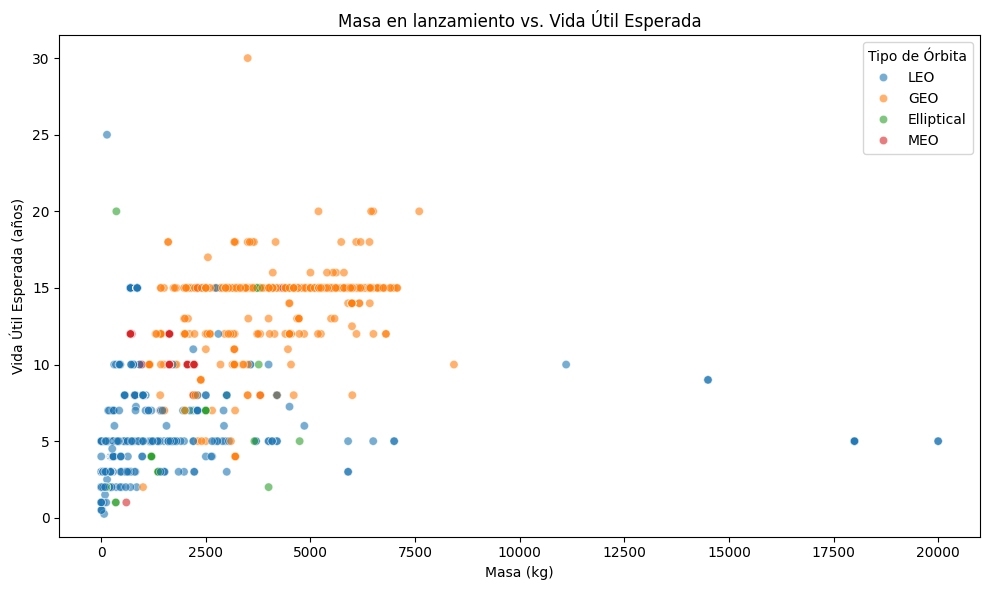

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_analisis,
    x='Launch_Mass_kg',
    y='Expected_Lifetime_yrs',
    hue='Class_of_Orbit',   # Categoría de órbita: LEO, MEO, GEO, etc.
    alpha=0.6
)
plt.title('Masa en lanzamiento vs. Vida Útil Esperada')
plt.xlabel('Masa (kg)')
plt.ylabel('Vida Útil Esperada (años)')
plt.legend(title='Tipo de Órbita')
plt.tight_layout()
plt.show()

In [ ]:
# Guardar el DataFrame como CSV
#df_analisis.to_csv('df_analisis_exportado.csv', index=False)

# Código para descargarlo en tu PC
#from google.colab import files
#files.download('df_analisis_exportado.csv')

# Convertimos variables categóricas en numéricas

In [ ]:
#veamos nuevamente que hay en cada variable categórica

for col in ['Class_of_Orbit','Type_of_Orbit','Date of Launch', 'OBJECT_TYPE', 'Purpose_Grouped']:
    print(f"\nValores únicos en {col}:")
    print(df_analisis[col].unique())


Valores únicos en Class_of_Orbit:
['LEO' 'GEO' 'Elliptical' 'MEO']

Valores únicos en Type_of_Orbit:
['Non-Polar Inclined' 'Sun-Synchronous' None 'Equatorial' 'Polar'
 'Elliptical' 'Deep Highly Eccentric' 'Molniya' 'Retrograde' 'Cislunar'
 'Sun-Synchronous near polar']

Valores únicos en Date of Launch:
<DatetimeArray>
['2019-12-11 00:00:00', '2023-01-03 00:00:00', '2017-06-23 00:00:00',
 '2016-04-25 00:00:00', '2014-02-06 00:00:00', '2016-06-15 00:00:00',
 '2015-03-02 00:00:00', '2004-03-13 00:00:00', '1999-09-26 00:00:00',
 '2023-04-15 00:00:00',
 ...
 '2021-08-05 00:00:00', '2007-07-06 00:00:00', '2019-03-11 00:00:00',
 '2008-06-09 00:00:00', '2021-09-09 00:00:00', '2019-09-19 00:00:00',
 '2018-04-26 00:00:00', '2011-12-22 00:00:00', '2019-09-14 00:00:00',
 '2012-01-09 00:00:00']
Length: 1186, dtype: datetime64[ns]

Valores únicos en OBJECT_TYPE:
['PAYLOAD']

Valores únicos en Purpose_Grouped:
['Earth Observation' 'Technology Development' 'Communications'
 'Navigation/Regional Posi

Teniendo en cuenta que la variable 'Class_of_Orbit' tiene un cierto orden, le aplicamos OrdinalEncoder:

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()

df_analisis['Class_of_Orbit_Encoded'] = ordinal_encoder.fit_transform(df_analisis[['Class_of_Orbit']])

In [ ]:
df_analisis.drop('Class_of_Orbit', axis=1, inplace=True)

In [ ]:
#corroboramos que los datos hayan sido bien convertidos

df_analisis['Class_of_Orbit_Encoded'].unique()

array([2., 1., 0., 3.])

Para el resto de las variables ('Type_of_Orbit', 'OBJECT_TYPE', 'Purpose_Grouped'), aplicamos OneHotEncoder:

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

columnas_a_codificar = ['Type_of_Orbit', 'OBJECT_TYPE', 'Purpose_Grouped']

onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

encoded_array = onehot_encoder.fit_transform(df_analisis[columnas_a_codificar])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=onehot_encoder.get_feature_names_out(columnas_a_codificar)
)

df_analisis = df_analisis.reset_index(drop=True)
encoded_df = encoded_df.reset_index(drop=True)

df_analisis = pd.concat([df_analisis, encoded_df], axis=1)

df_analisis.drop(columnas_a_codificar, axis=1, inplace=True)

In [ ]:
df_analisis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5886 entries, 0 to 5885
Data columns (total 24 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Eccentricity                                     5879 non-null   float64       
 1   Inclination (degrees)                            5883 non-null   float64       
 2   Launch_Mass_kg                                   5654 non-null   float64       
 3   Date of Launch                                   5884 non-null   datetime64[ns]
 4   Expected_Lifetime_yrs                            3953 non-null   float64       
 5   DECAY                                            1304 non-null   datetime64[ns]
 6   PERIOD                                           5843 non-null   float64       
 7   Class_of_Orbit_Encoded                           5886 non-null   float64       
 8   Type_of_Orbit_Cislunar                

En la columna 'Date_of_Launch' extraemos el año, mes y día, y luego eliminamos la columna original:

In [ ]:
df_analisis['anio_DtOfLaunch'] = df_analisis['Date of Launch'].dt.year
df_analisis['mes_DtOfLaunch'] = df_analisis['Date of Launch'].dt.month
df_analisis['dia_DtOfLaunch'] = df_analisis['Date of Launch'].dt.day



# df_analisis['anio_DtOfLaunch'] = df_analisis['Date of Launch'].apply(lambda x: x.year if pd.notnull(x) else pd.NA)
# df_analisis['mes_DtOfLaunch'] = df_analisis['Date of Launch'].apply(lambda x: x.month if pd.notnull(x) else pd.NA)
# df_analisis['dia_DtOfLaunch'] = df_analisis['Date of Launch'].apply(lambda x: x.day if pd.notnull(x) else pd.NA)

df_analisis.drop('Date of Launch', axis=1, inplace=True)
# df_analisis['Date of Launch']= pd.to_datetime( df_analisis['Date of Launch'], errors='coerce')

In [ ]:
df_analisis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5886 entries, 0 to 5885
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Eccentricity                                     5879 non-null   float64       
 1   Inclination (degrees)                            5883 non-null   float64       
 2   Launch_Mass_kg                                   5654 non-null   float64       
 3   Expected_Lifetime_yrs                            3953 non-null   float64       
 4   DECAY                                            1304 non-null   datetime64[ns]
 5   PERIOD                                           5843 non-null   float64       
 6   Class_of_Orbit_Encoded                           5886 non-null   float64       
 7   Type_of_Orbit_Cislunar                           5886 non-null   float64       
 8   Type_of_Orbit_Deep Highly Eccentric   

In [ ]:
validationData = df_analisis[df_analisis['Expected_Lifetime_yrs'].isnull()]
# df_analisis = df_analisis[df_analisis['Expected_Lifetime_yrs'].notnull()]
validationData['Expected_Lifetime_yrs'] = 0

/tmp/ipython-input-4002667884.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
validationData.shape, df_analisis.shape

((1933, 26), (5886, 26))

# Imputación de NaN

 Realizamos la imputación de valores faltantes (NaN) usando el método **IterativeImputer** de sklearn:

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

np.random.seed(0)
columns = ['Eccentricity','anio_DtOfLaunch','mes_DtOfLaunch','dia_DtOfLaunch','Inclination (degrees)','PERIOD', 'Launch_Mass_kg','Expected_Lifetime_yrs']
imputador = IterativeImputer(random_state=0)
df_imputado = imputador.fit_transform(df_analisis[columns])
#df_analisis = pd.DataFrame(df_imputado, columns=columns)
df_imputado_df = pd.DataFrame(df_imputado, columns=columns, index=df_analisis.index)
df_analisis[columns] = df_imputado_df

In [ ]:
df_analisis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5886 entries, 0 to 5885
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Eccentricity                                     5886 non-null   float64       
 1   Inclination (degrees)                            5886 non-null   float64       
 2   Launch_Mass_kg                                   5886 non-null   float64       
 3   Expected_Lifetime_yrs                            5886 non-null   float64       
 4   DECAY                                            1304 non-null   datetime64[ns]
 5   PERIOD                                           5886 non-null   float64       
 6   Class_of_Orbit_Encoded                           5886 non-null   float64       
 7   Type_of_Orbit_Cislunar                           5886 non-null   float64       
 8   Type_of_Orbit_Deep Highly Eccentric   

In [ ]:
df_analisis

,Eccentricity,Inclination (degrees),Launch_Mass_kg,Expected_Lifetime_yrs,DECAY,PERIOD,Class_of_Orbit_Encoded,Type_of_Orbit_Cislunar,Type_of_Orbit_Deep Highly Eccentric,Type_of_Orbit_Elliptical,...,Type_of_Orbit_Sun-Synchronous near polar,Type_of_Orbit_None,OBJECT_TYPE_PAYLOAD,Purpose_Grouped_Communications,Purpose_Grouped_Earth Observation,Purpose_Grouped_Navigation/Regional Positioning,Purpose_Grouped_Technology Development,anio_DtOfLaunch,mes_DtOfLaunch,dia_DtOfLaunch
0,0.001510,36.90,22.0,0.500000,NaT,95.46,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2019.0,12.0,11.0
1,0.001510,98.00,4.0,2.912046,NaT,96.85,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2023.0,1.0,3.0
2,0.001450,97.45,4.5,2.000000,2024-09-01,87.43,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2017.0,6.0,23.0
3,0.001510,98.20,1.0,4.130448,2023-09-08,87.89,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2016.0,4.0,25.0
4,0.000178,0.08,6330.0,15.000000,NaT,1436.10,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2014.0,2.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5881,0.000700,98.56,1500.0,6.410698,NaT,100.16,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2011.0,12.0,22.0
5882,0.000702,98.50,2650.0,5.000000,NaT,100.32,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2019.0,9.0,14.0
5883,0.000291,97.50,2650.0,4.000000,NaT,92.86,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2012.0,1.0,9.0
5884,0.000947,97.50,2630.0,4.000000,NaT,94.67,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2016.0,5.0,29.0


# Escalamos/normalizamos los datos numéricos

Para saber si escalamos o normalizamos, analicemos si las distribuciones son normales mediante el test **Normaltest** y el diagrama Q-Q.

In [ ]:
import numpy as np
from scipy.stats import normaltest

# Lista de columnas a evaluar
columnas = [
     'Eccentricity',
    'Inclination (degrees)', 'Launch_Mass_kg', 'Expected_Lifetime_yrs', 'PERIOD'
]

# Evaluar cada columna
for col in columnas:
    datos = df_analisis[col].replace([np.inf, -np.inf], np.nan).dropna()

    if len(datos) < 8:
        print(f"\n Columna '{col}': No se puede aplicar normaltest (requiere al menos 8 datos).")
        continue

    stat, p = normaltest(datos)

    print(f"\n Normaltest para columna: '{col}'")
    print(f"   Estadístico: {stat:.4f} | p-valor: {p:.4f}")
    if p > 0.05:
        print("   Compatible con distribución normal (no se rechaza H0)")
    else:
        print("   No sigue distribución normal (se rechaza H0)")


 Normaltest para columna: 'Eccentricity'
   Estadístico: 19142.9217 | p-valor: 0.0000
   No sigue distribución normal (se rechaza H0)

 Normaltest para columna: 'Inclination (degrees)'
   Estadístico: 192.2906 | p-valor: 0.0000
   No sigue distribución normal (se rechaza H0)

 Normaltest para columna: 'Launch_Mass_kg'
   Estadístico: 5421.2041 | p-valor: 0.0000
   No sigue distribución normal (se rechaza H0)

 Normaltest para columna: 'Expected_Lifetime_yrs'
   Estadístico: 19127.6527 | p-valor: 0.0000
   No sigue distribución normal (se rechaza H0)

 Normaltest para columna: 'PERIOD'
   Estadístico: 10644.0592 | p-valor: 0.0000
   No sigue distribución normal (se rechaza H0)


Eliminamos el valor outlier de 'Eccentricity' para revisar si se ajusta a la distribucion normal.

In [ ]:
df_analisis = df_analisis[df_analisis['Eccentricity'] <= 500]

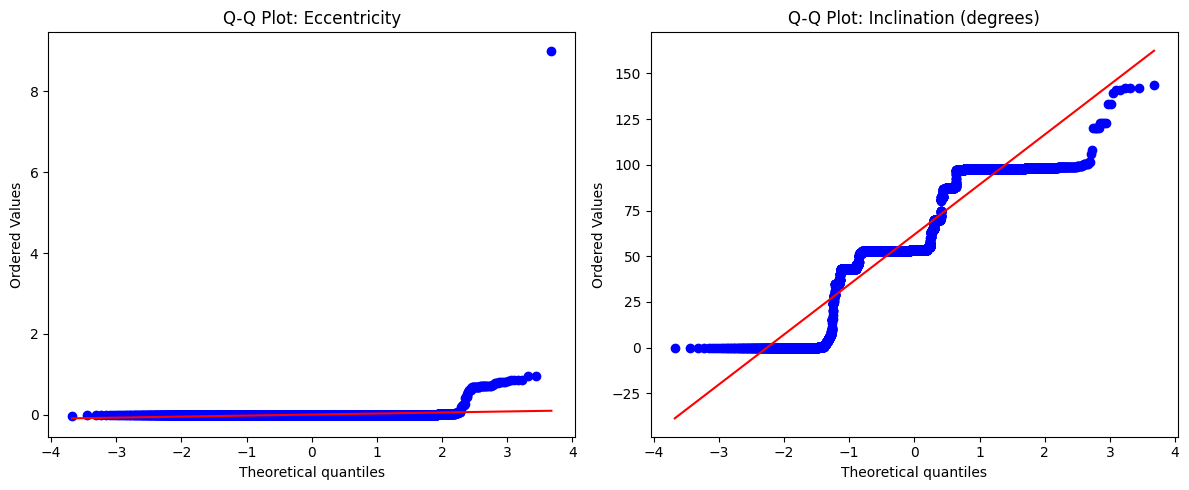

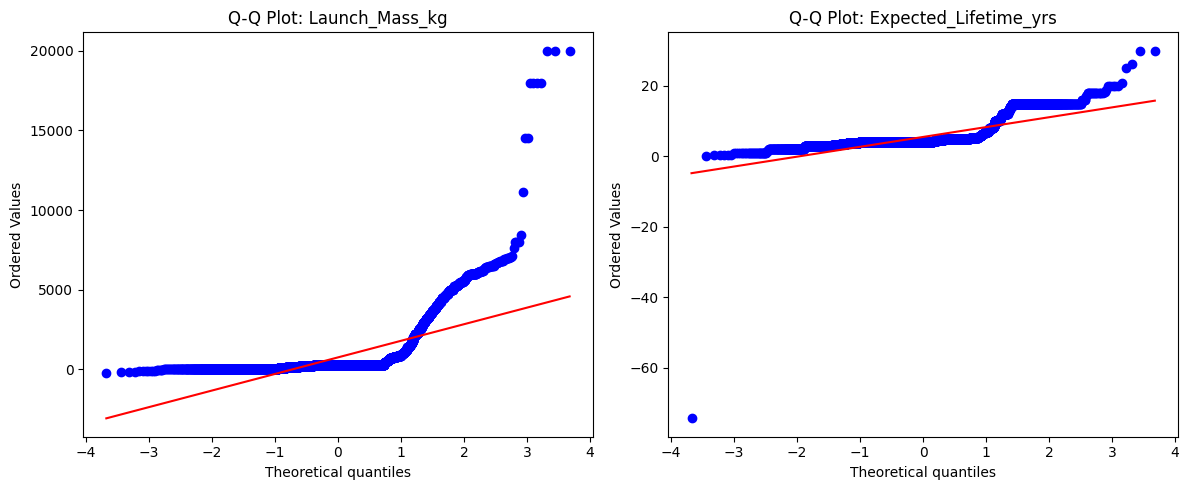

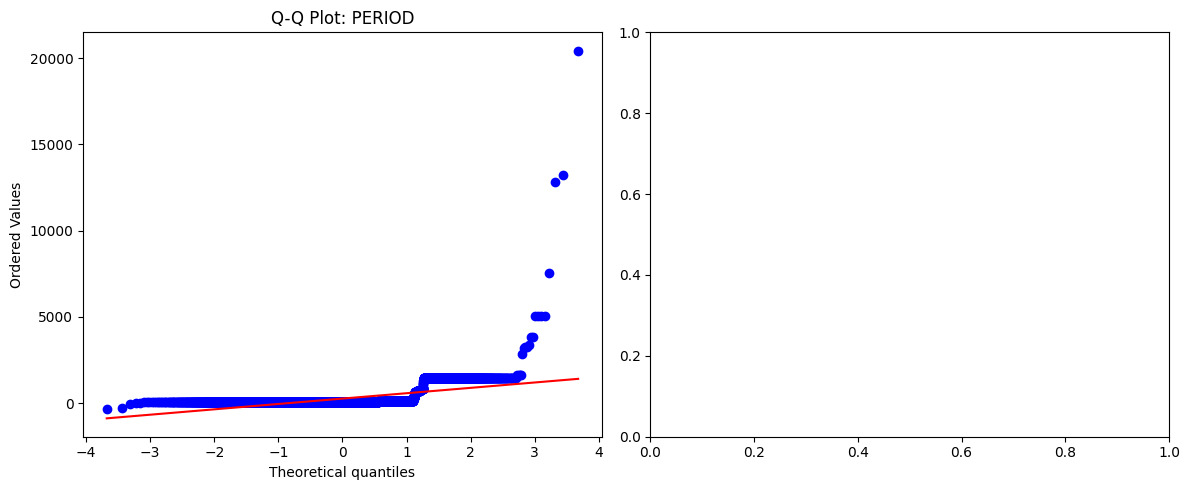

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import probplot

# Lista de columnas a graficar
# cols = ['Eccentricity', 'Inclination (degrees)', 'Launch_Mass_kg',
#        'Expected_Lifetime_yrs', 'PERIOD', 'Class_of_Orbit_Encoded',
#        'Type_of_Orbit_Cislunar', 'Type_of_Orbit_Deep Highly Eccentric',
#        'Type_of_Orbit_Elliptical', 'Type_of_Orbit_Equatorial',
#        'Type_of_Orbit_Molniya', 'Type_of_Orbit_Non-Polar Inclined',
#        'Type_of_Orbit_Polar', 'Type_of_Orbit_Retrograde',
#        'Type_of_Orbit_Sun-Synchronous',
#        'Type_of_Orbit_Sun-Synchronous near polar', 'Type_of_Orbit_None',
#        'OBJECT_TYPE_PAYLOAD', 'Purpose_Grouped_Communications',
#        'Purpose_Grouped_Earth Observation',
#        'Purpose_Grouped_Navigation/Regional Positioning',
#        'Purpose_Grouped_Technology Development', 'anio_DtOfLaunch',
#        'mes_DtOfLaunch', 'dia_DtOfLaunch']
cols = [
    'Eccentricity',
    'Inclination (degrees)', 'Launch_Mass_kg', 'Expected_Lifetime_yrs', 'PERIOD'
]

# Preparar pares de columnas y graficar
for i in range(0, len(cols), 2):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for j in range(2):
        if i + j < len(cols):
            col = cols[i + j]
            datos = df_analisis[col].dropna()
            probplot(datos, dist="norm", plot=axes[j])
            axes[j].set_title(f'Q-Q Plot: {col}')
            axes[j].grid(False)

    plt.tight_layout()
    plt.show()

En los graficos Q-Q (cuantil-cuantil) podemos ver que los datos de las columnas  'Inclination (degrees)', 'Launch_Mass_kg', 'PERIOD' no se aproximan a la recta, por lo tanto no tienen una distribución normal.

Dado que verificamos (analitica y graficamente) que hay columnas cuyas distribuciones no son normales, para escalar los datos vamos a utilizar **MinMaxScaler** ya que este no depende de la distribución como StandardScaler, pero es sensible a outliers (los cuales ya limpiamos).
En otras columnas ('Eccentricity' y 'Expected_Lifetime_yrs') verificamos que las distribuciones si son normales y aplicaremos StandarScaler.

In [ ]:
from sklearn.preprocessing import StandardScaler

df_Scaled = df_analisis.copy()
columnsToStandarScaler = [
'Expected_Lifetime_yrs',
'Eccentricity']

standarScaler = StandardScaler()
df_Scaled[columnsToStandarScaler] = standarScaler.fit_transform(df_analisis[columnsToStandarScaler])

In [ ]:
df_Scaled

,Eccentricity,Inclination (degrees),Launch_Mass_kg,Expected_Lifetime_yrs,DECAY,PERIOD,Class_of_Orbit_Encoded,Type_of_Orbit_Cislunar,Type_of_Orbit_Deep Highly Eccentric,Type_of_Orbit_Elliptical,...,Type_of_Orbit_Sun-Synchronous near polar,Type_of_Orbit_None,OBJECT_TYPE_PAYLOAD,Purpose_Grouped_Communications,Purpose_Grouped_Earth Observation,Purpose_Grouped_Navigation/Regional Positioning,Purpose_Grouped_Technology Development,anio_DtOfLaunch,mes_DtOfLaunch,dia_DtOfLaunch
0,-0.059042,36.90,22.0,-1.394985,NaT,95.46,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2019.0,12.0,11.0
1,-0.059042,98.00,4.0,-0.724225,NaT,96.85,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2023.0,1.0,3.0
2,-0.059484,97.45,4.5,-0.977854,2024-09-01,87.43,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2017.0,6.0,23.0
3,-0.059042,98.20,1.0,-0.385403,2023-09-08,87.89,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2016.0,4.0,25.0
4,-0.068851,0.08,6330.0,2.637283,NaT,1436.10,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,2014.0,2.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5881,-0.065003,98.56,1500.0,0.248706,NaT,100.16,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2011.0,12.0,22.0
5882,-0.064992,98.50,2650.0,-0.143591,NaT,100.32,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2019.0,9.0,14.0
5883,-0.068018,97.50,2650.0,-0.421679,NaT,92.86,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2012.0,1.0,9.0
5884,-0.063188,97.50,2630.0,-0.421679,NaT,94.67,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2016.0,5.0,29.0


In [ ]:
# ESCALAR DATOS

# Import MinMaxScaler from sklearn
from sklearn.preprocessing import MinMaxScaler

# Initialize MinMax
scaler = MinMaxScaler()

# Define the columns to scale (numeric columns)
columns_to_scale = ['Inclination (degrees)', 'Launch_Mass_kg', 'PERIOD','anio_DtOfLaunch','mes_DtOfLaunch', 'dia_DtOfLaunch']

# Scale the selected columns and create new columns with the scaled data
df_Scaled[columns_to_scale] =    scaler.fit_transform(df_Scaled[columns_to_scale])
# for col in columns_to_scale:
#     df_analisis[f'{col}_scaled'] =

In [ ]:
df_Scaled

,Eccentricity,Inclination (degrees),Launch_Mass_kg,Expected_Lifetime_yrs,DECAY,PERIOD,Class_of_Orbit_Encoded,Type_of_Orbit_Cislunar,Type_of_Orbit_Deep Highly Eccentric,Type_of_Orbit_Elliptical,...,Type_of_Orbit_Sun-Synchronous near polar,Type_of_Orbit_None,OBJECT_TYPE_PAYLOAD,Purpose_Grouped_Communications,Purpose_Grouped_Earth Observation,Purpose_Grouped_Navigation/Regional Positioning,Purpose_Grouped_Technology Development,anio_DtOfLaunch,mes_DtOfLaunch,dia_DtOfLaunch
0,-0.059042,0.257322,0.012071,-1.394985,NaT,0.021291,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.918367,1.000000,0.333333
1,-0.059042,0.683403,0.011181,-0.724225,NaT,0.021358,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.000000,0.000000,0.066667
2,-0.059484,0.679568,0.011206,-0.977854,2024-09-01,0.020905,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.877551,0.454545,0.733333
3,-0.059042,0.684798,0.011033,-0.385403,2023-09-08,0.020927,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.857143,0.272727,0.800000
4,-0.068851,0.000558,0.324007,2.637283,NaT,0.085819,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.816327,0.090909,0.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5881,-0.065003,0.687308,0.085159,0.248706,NaT,0.021517,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.755102,1.000000,0.700000
5882,-0.064992,0.686890,0.142028,-0.143591,NaT,0.021525,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.918367,0.727273,0.433333
5883,-0.068018,0.679916,0.142028,-0.421679,NaT,0.021166,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.775510,0.000000,0.266667
5884,-0.063188,0.679916,0.141039,-0.421679,NaT,0.021253,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.857143,0.363636,0.933333


In [ ]:
validationData = df_Scaled[df_Scaled.index.isin(validationData.index)]
df_Scaled = df_Scaled[~df_Scaled.index.isin(validationData.index)]

In [ ]:
validationData.shape, df_Scaled.shape

((1931, 26), (3953, 26))

In [ ]:
df_Scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3953 entries, 0 to 5884
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Eccentricity                                     3953 non-null   float64       
 1   Inclination (degrees)                            3953 non-null   float64       
 2   Launch_Mass_kg                                   3953 non-null   float64       
 3   Expected_Lifetime_yrs                            3953 non-null   float64       
 4   DECAY                                            630 non-null    datetime64[ns]
 5   PERIOD                                           3953 non-null   float64       
 6   Class_of_Orbit_Encoded                           3953 non-null   float64       
 7   Type_of_Orbit_Cislunar                           3953 non-null   float64       
 8   Type_of_Orbit_Deep Highly Eccentric        

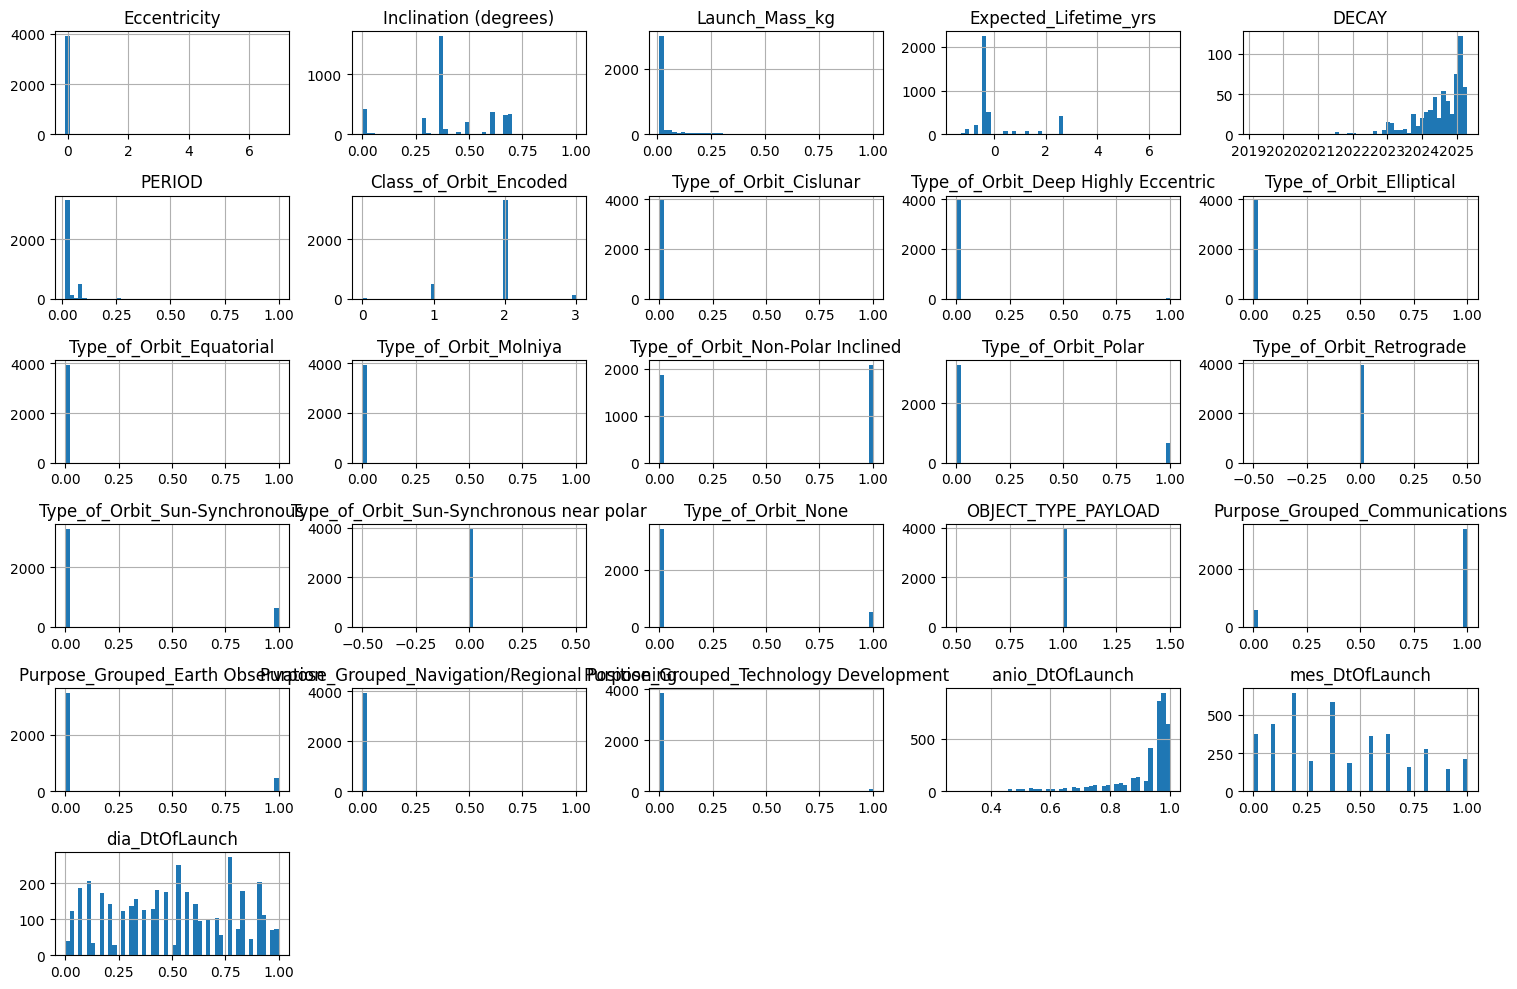

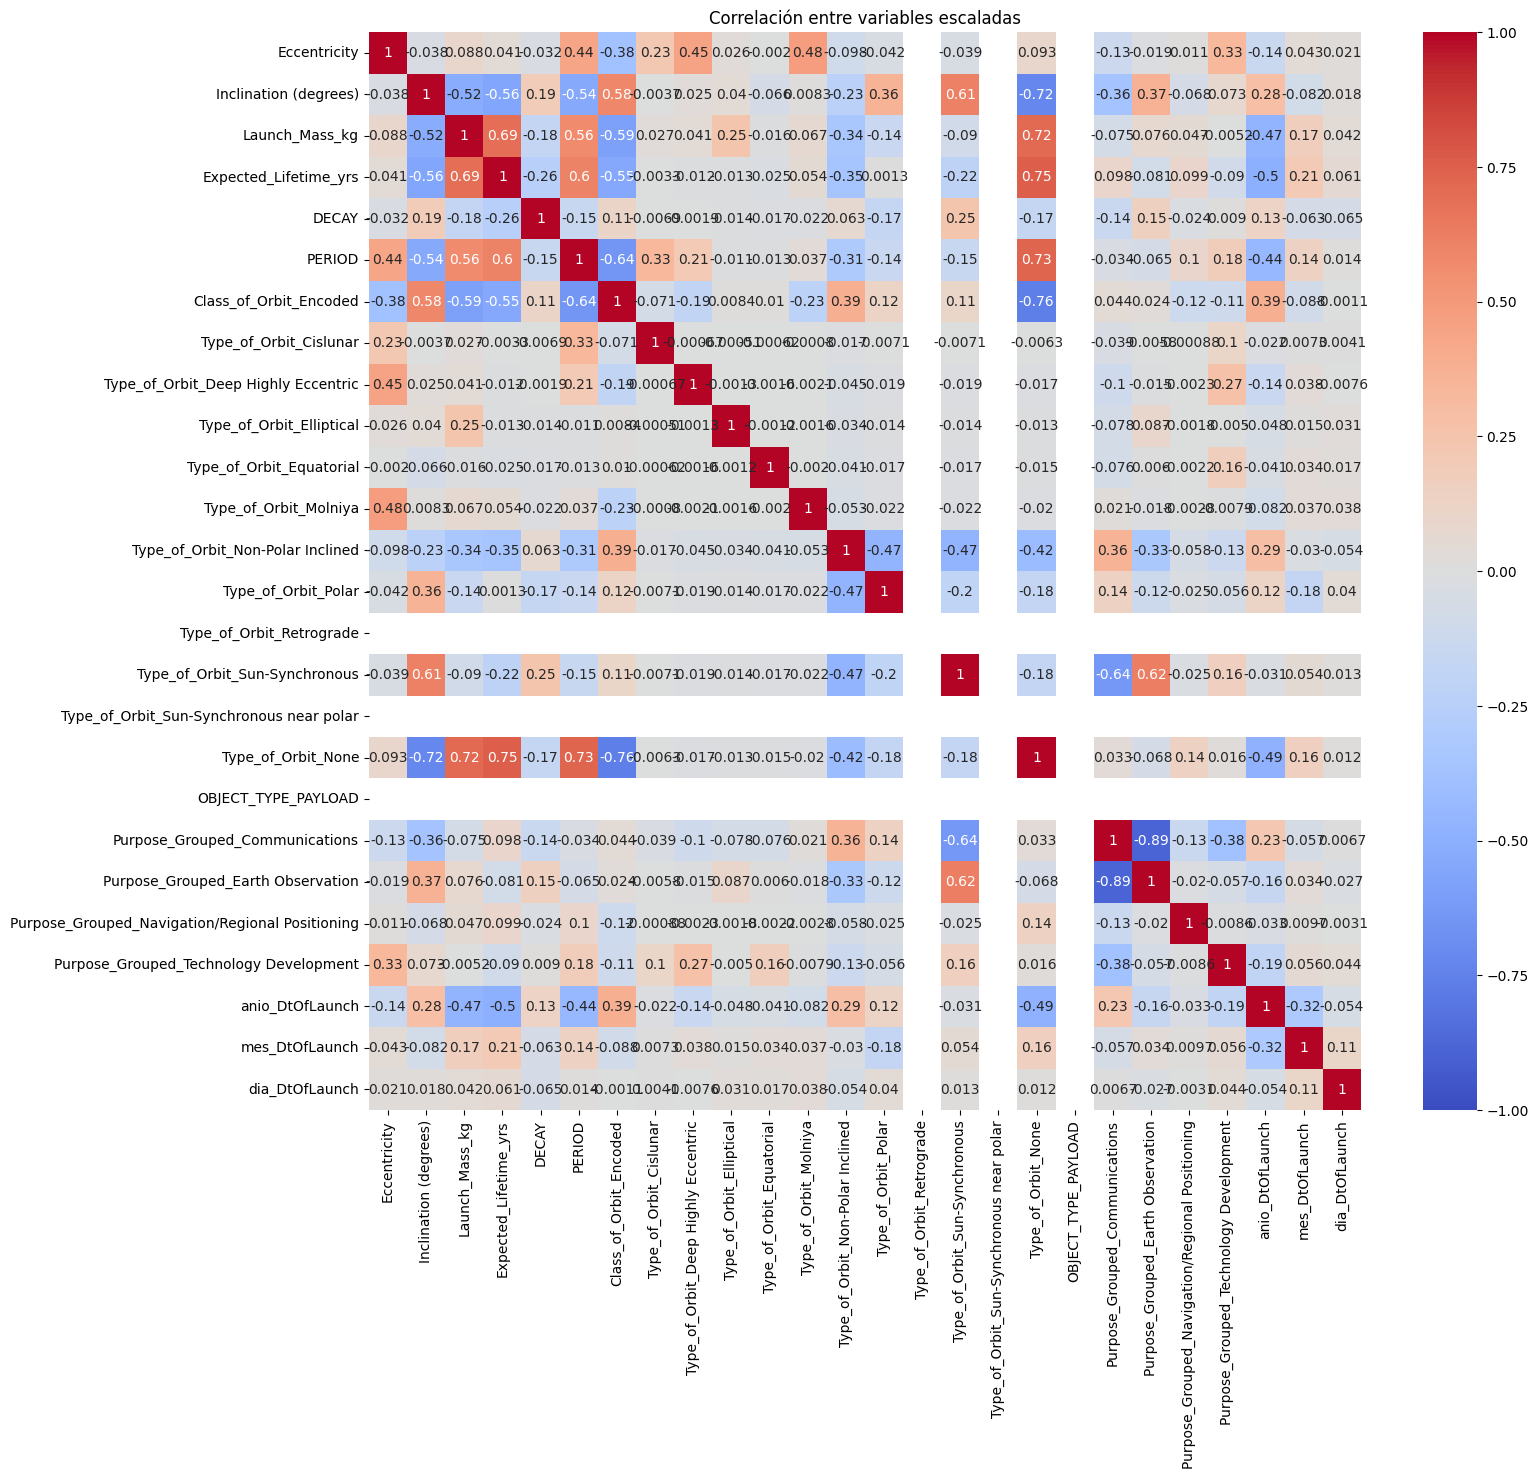

/tmp/ipython-input-153865650.py:24: UserWarning:

Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.



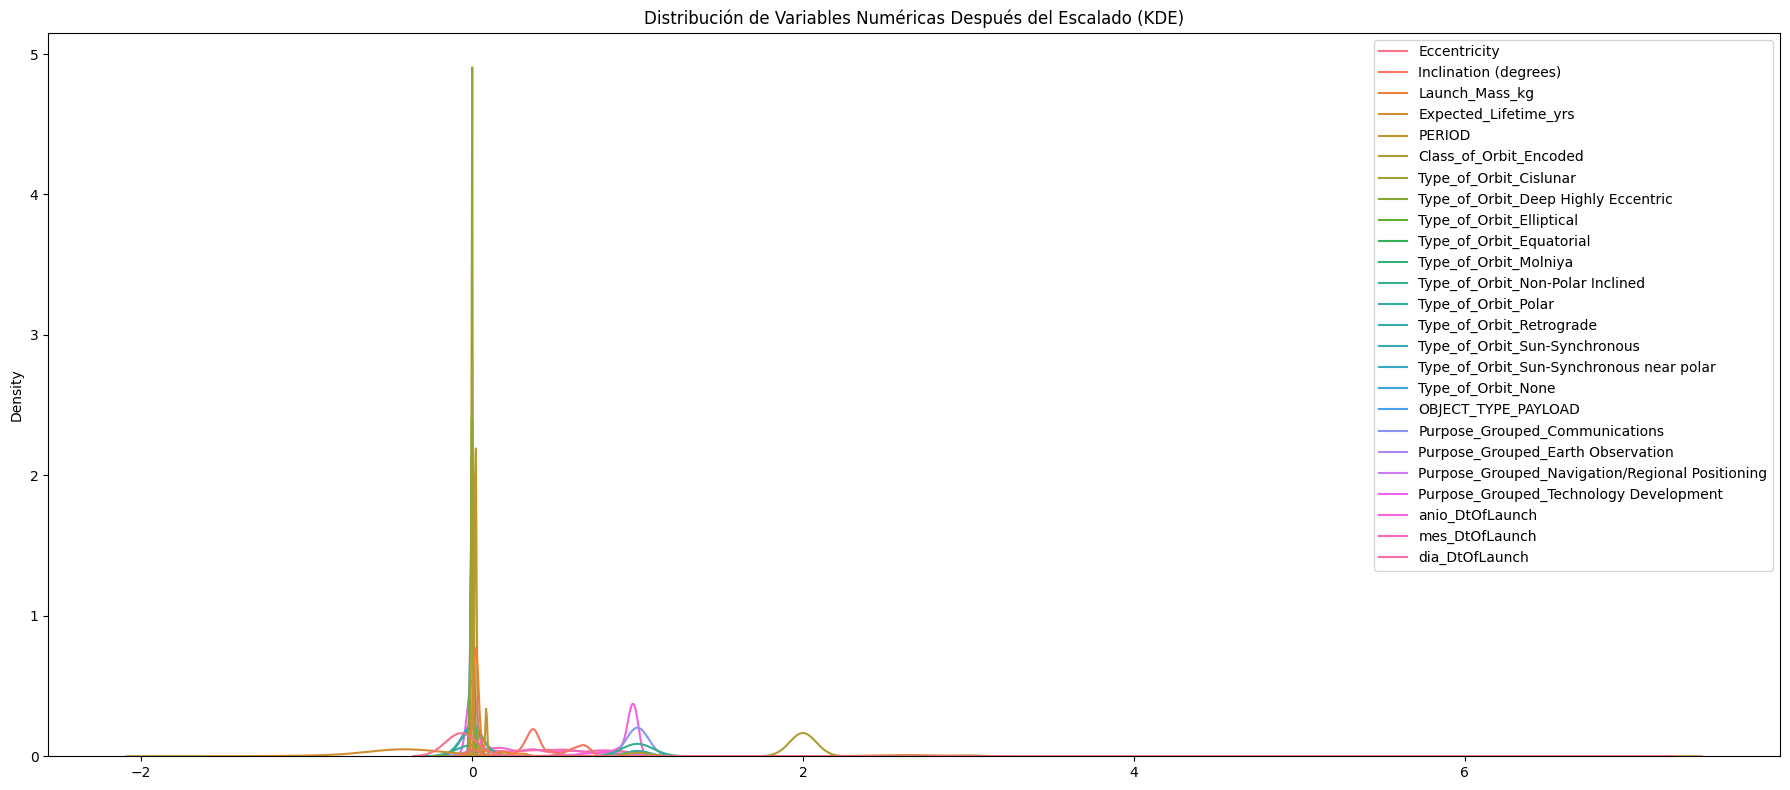

In [ ]:
# Seleccionar solo las columnas escaladas
# df_scaled = df_Scaled[[col for col in df_analisis.columns if '_scaled' in col]]

# Visualizar datos escalados
#plt.figure(figsize=(14, 8))
#sns.boxplot(data=df_scaled, orient='h', palette='viridis')
#plt.title('Distribución de Variables Numéricas Después del Escalado (MinMax)')
#plt.xlabel('Valores Escalados')
#plt.tight_layout()
#plt.show()


df_Scaled.hist(figsize=(15, 10), bins=50)
plt.tight_layout()
plt.show()


plt.figure(figsize=(16, 14))
sns.heatmap(df_Scaled.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlación entre variables escaladas")
plt.show()

plt.figure(figsize=(18, 8))
sns.kdeplot(data=df_Scaled)
plt.title('Distribución de Variables Numéricas Después del Escalado (KDE)')
plt.tight_layout()
plt.show()

En los graficos podemos ver:

* Launch_Mass_kg, Inclination, Expected_Lifetime_yrs y PERIOD tienen distribuciones fuertemente sesgadas hacia la izquierda, con la mayoría de los valores concentrados cerca del mínimo (0).

* En el grafico KDE, vemos que las curvas están todas centradas en valores cercanos a 0, con colas a derecha o izquierda.

* Variables como Type_of_Orbit_None, Type_of_Orbit_Encoded, y OBJECT_TYPE_PAYLOAD están altamente correlacionadas entre sí (posiblemente porque codifican la misma dimensión). Esto sugiere redundancia o necesidad de reducción de dimensionalidad (PCA).

# PCA

Aplicamos PCA para reducir la dimensionalidad de los datos, manteniendo la mayor cantidad de información posible.

In [ ]:
df_Scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3953 entries, 0 to 5884
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Eccentricity                                     3953 non-null   float64       
 1   Inclination (degrees)                            3953 non-null   float64       
 2   Launch_Mass_kg                                   3953 non-null   float64       
 3   Expected_Lifetime_yrs                            3953 non-null   float64       
 4   DECAY                                            630 non-null    datetime64[ns]
 5   PERIOD                                           3953 non-null   float64       
 6   Class_of_Orbit_Encoded                           3953 non-null   float64       
 7   Type_of_Orbit_Cislunar                           3953 non-null   float64       
 8   Type_of_Orbit_Deep Highly Eccentric        

In [ ]:
tp = df_Scaled.columns.difference(['DECAY'])
tp.shape, df_Scaled.shape

((25,), (3953, 26))

Cargas de las variables en los primeros componentes principales:
                             PC1       PC2       PC3       PC4       PC5  \
Class_of_Orbit_Encoded -0.231355  0.119478 -0.379393 -0.007732  0.593862   
Eccentricity            0.041493 -0.168549  0.848552  0.158205  0.401285   
Expected_Lifetime_yrs   0.912525  0.095696 -0.154691 -0.086453  0.300633   
Inclination (degrees)  -0.099205 -0.162077 -0.098590  0.087317  0.218197   
Launch_Mass_kg          0.050093 -0.012342  0.010781 -0.024849 -0.037433   

                             PC6       PC7       PC8       PC9      PC10  ...  \
Class_of_Orbit_Encoded -0.051538 -0.103129  0.176097  0.367593  0.496722  ...   
Eccentricity           -0.061447 -0.054059  0.125583 -0.021873  0.183577  ...   
Expected_Lifetime_yrs  -0.109772  0.002578  0.106327 -0.031100 -0.101582  ...   
Inclination (degrees)   0.016093 -0.077995  0.118523 -0.118944 -0.155403  ...   
Launch_Mass_kg          0.001461  0.014921 -0.023343  0.015715  0.048980 

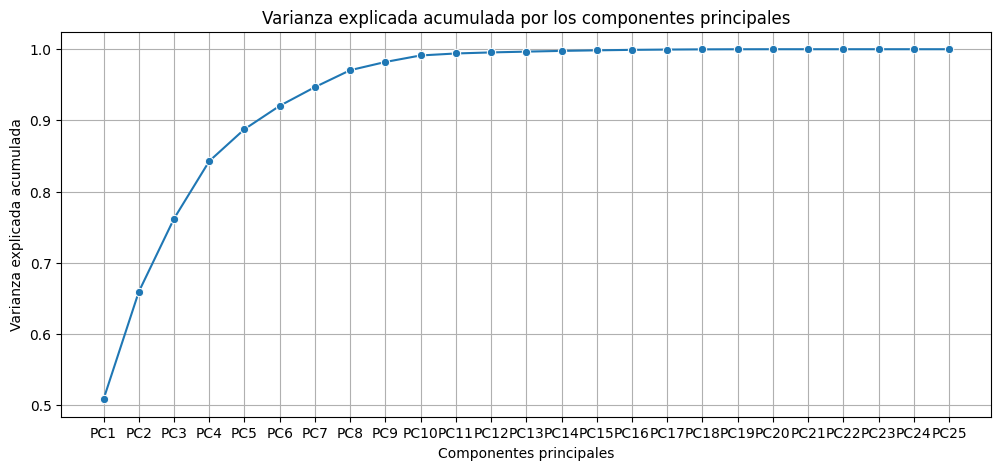

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()

df_ToPca = df_Scaled[tp]

pca_result = pca.fit_transform(df_ToPca)

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_ToPca.columns
)

print("Cargas de las variables en los primeros componentes principales:")
print(loadings.head())

explained_variance = pca.explained_variance_ratio_

print("\nVarianza explicada por cada componente:")
for var_name, var_ratio in zip(loadings.columns, explained_variance):
    print(f"{var_name}: {var_ratio:.4f}")

plt.figure(figsize=(12, 5))
sns.lineplot(x=loadings.columns, y=explained_variance.cumsum(), marker='o')
plt.title('Varianza explicada acumulada por los componentes principales')
plt.xlabel('Componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.grid(True)
plt.show()

Estos resultados nos indican que:

* Los primeros 3 componentes explican el 78.4% de la varianza, lo que sugiere una reducción de dimensionalidad efectiva. Los primeros componentes están fuertemente dominados por variables orbitales y de duración, no tanto por masa ni inclinación.

* A partir de PC4 en adelante, la varianza explicada cae rápidamente, lo que indica que esos componentes capturan poca información relevante.

Conclusión: Se puede trabajar con los primeros 2 o 3 componentes y conservar más del 75% de la información original. PC1 y PC2 capturan dimensiones físicas relacionadas con la dinámica orbital (Eccentricity, Expected_Lifetime_yrs).

# Finalmente, dividimos de la siguiente manera los datos en entrenamiento, evaluación y test:

In [ ]:
from sklearn.model_selection import train_test_split

columns = ['Eccentricity', 'Inclination (degrees)', 'Launch_Mass_kg', 'DECAY', 'PERIOD']

X_train, X_test, y_train, y_test = train_test_split(df_analisis[columns], df_analisis['Expected_Lifetime_yrs'], test_size=0.2, random_state=42)

print("Training set shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing set shape (X_test, y_test):", X_test.shape, y_test.shape)

Training set shape (X_train, y_train): (4707, 5) (4707,)
Testing set shape (X_test, y_test): (1177, 5) (1177,)


# **Practico 3 - Aprendizaje Supervisado y/o No Supervisado**


# Aprendizaje no supervisado


Dado que las técnicas de aprendizaje no supervisado nos ofrecen herramientas de análisis exploratorio, decidimos comenzar con este enfoque previo a realizar cualquier otro tipo de aprendizaje supervisado, pues podrían surgir patrones ocultos en nuestro dataset que no teníamos previstos de antemano.



In [ ]:
df_Scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3953 entries, 0 to 5884
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Eccentricity                                     3953 non-null   float64       
 1   Inclination (degrees)                            3953 non-null   float64       
 2   Launch_Mass_kg                                   3953 non-null   float64       
 3   Expected_Lifetime_yrs                            3953 non-null   float64       
 4   DECAY                                            630 non-null    datetime64[ns]
 5   PERIOD                                           3953 non-null   float64       
 6   Class_of_Orbit_Encoded                           3953 non-null   float64       
 7   Type_of_Orbit_Cislunar                           3953 non-null   float64       
 8   Type_of_Orbit_Deep Highly Eccentric        

In [ ]:
df_Scaled.head()

,Eccentricity,Inclination (degrees),Launch_Mass_kg,Expected_Lifetime_yrs,DECAY,PERIOD,Class_of_Orbit_Encoded,Type_of_Orbit_Cislunar,Type_of_Orbit_Deep Highly Eccentric,Type_of_Orbit_Elliptical,...,Type_of_Orbit_Sun-Synchronous near polar,Type_of_Orbit_None,OBJECT_TYPE_PAYLOAD,Purpose_Grouped_Communications,Purpose_Grouped_Earth Observation,Purpose_Grouped_Navigation/Regional Positioning,Purpose_Grouped_Technology Development,anio_DtOfLaunch,mes_DtOfLaunch,dia_DtOfLaunch
0,-0.059042,0.257322,0.012071,-1.394985,NaT,0.021291,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.918367,1.000000,0.333333
2,-0.059484,0.679568,0.011206,-0.977854,2024-09-01,0.020905,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.877551,0.454545,0.733333
4,-0.068851,0.000558,0.324007,2.637283,NaT,0.085819,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.816327,0.090909,0.166667
5,-0.070161,0.000000,0.099995,2.637283,NaT,0.085820,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.857143,0.454545,0.466667
6,-0.068852,0.000697,0.109885,2.637283,NaT,0.085819,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.836735,0.181818,0.033333


In [ ]:
# Eliminar la columna datetime 'DECAY' ya que se trata de una fecha
df_num = df_Scaled.drop(columns=['DECAY'])

## Clustering con DBSCAN

Procederemos primero con un analisis de clusters con DBSCAN puesto que no requiere elegir previamente un K optimo.

**eps**: radio máximo para considerar vecinos.

**min_samples**: número mínimo de puntos para formar un cluster.

Luego, los puntos que no pertenezcan a ningún cluster se marcan como -1 (ruido).

In [ ]:
import plotly.express as px

In [ ]:
from sklearn.cluster import DBSCAN

# --- DBSCAN ---
dbscan = DBSCAN(eps=2, min_samples=5)  # ajusta estos valores según tu dataset
labels = dbscan.fit_predict(df_num)

df_num['Cluster_DBSCAN'] = labels

# --- Reducción a 3D con PCA ---
pca_3d = PCA(n_components=3)
pca_data_3d = pca_3d.fit_transform(df_num.drop('Cluster_DBSCAN', axis=1))

# --- DataFrame PCA ---
df_pca = pd.DataFrame(pca_data_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster'] = df_num['Cluster_DBSCAN'].astype(str)

# --- Visualización interactiva ---
# --- Visualización interactiva ---
fig = px.scatter_3d(
    df_pca,
    x='PC1', y='PC2', z='PC3',
    color='Cluster',
    symbol='Cluster',
    opacity=0.7,
    title='Clusters con DBSCAN en 3D (PCA)'
)

fig.update_traces(marker=dict(size=5))

# Limitar eje PC1 hasta 10
fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-10, df_pca['PC1'].max()]),
        yaxis=dict(range=[df_pca['PC2'].min(), 10])
    )
)

fig.show()

## Clustering con K-Means

Probamos varios valores de K (por ejemplo de 2 a 10) y medimos dos métricas:

Inertia (Suma de distancias cuadradas intra-cluster) → para el método del codo

Coeficiente de silueta → para ver qué tan bien separados están los clusters

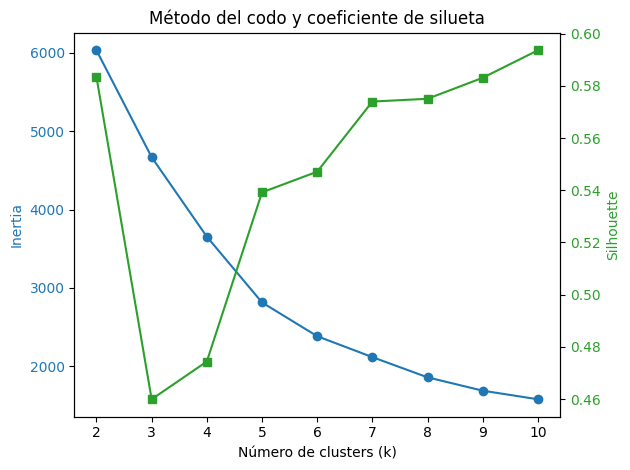

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# Rango de valores de K a evaluar
range_k = range(2, 11)

inertias = []
silhouettes = []

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_num)

    inertias.append(kmeans.inertia_)
    sil_score = silhouette_score(df_num, kmeans.labels_)
    silhouettes.append(sil_score)

# --- Graficar resultados ---
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('Número de clusters (k)')
ax1.set_ylabel('Inertia', color=color)
ax1.plot(range_k, inertias, marker='o', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Silhouette', color=color)
ax2.plot(range_k, silhouettes, marker='s', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Método del codo y coeficiente de silueta')
fig.tight_layout()
plt.show()


Analizando visualmente:

- Inertia (línea azul): desciende fuertemente hasta k=4, y luego el descenso es mucho más suave. Esto sugiere que el “codo” está en torno a k=4.

- Silhouette (línea verde): tiene valores más altos en k=2 y k=3, cae fuerte en k=4 Luego sube gradualmente y vuelve a ser alto en k=10.

Interpretación combinada:

k=2 y k=3 tienen mejor cohesión (silhouette más alto), pero poca segmentación.

k=4 es el “codo” claro en la inertia, pero tiene mala separación (silhouette bajo).

k≥7 empieza a tener silhouette decente (>0.48), aunque más clusters significa menos simplicidad.

In [ ]:
best_k = 3  # reemplaza por el valor que hayas elegido

kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_num['Cluster'] = kmeans_final.fit_predict(df_num)

### Visualización (2 componentes principales)

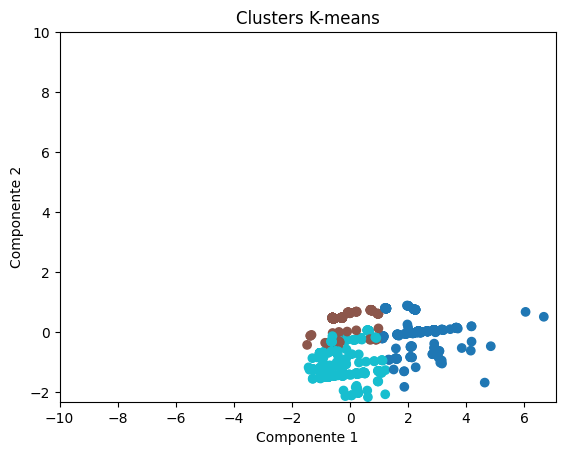

In [ ]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_num.drop('Cluster', axis=1))

plt.scatter(pca_data[:,0], pca_data[:,1], c=df_num['Cluster'], cmap='tab10')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Clusters K-means')

# Limitar los ejes
plt.xlim(-10, None)   # Eje X desde -10 hasta el máximo automático
plt.ylim(None, 10)    # Eje Y desde el mínimo automático hasta 10

plt.show()


## Clustering con Mezcla de Gaussianas

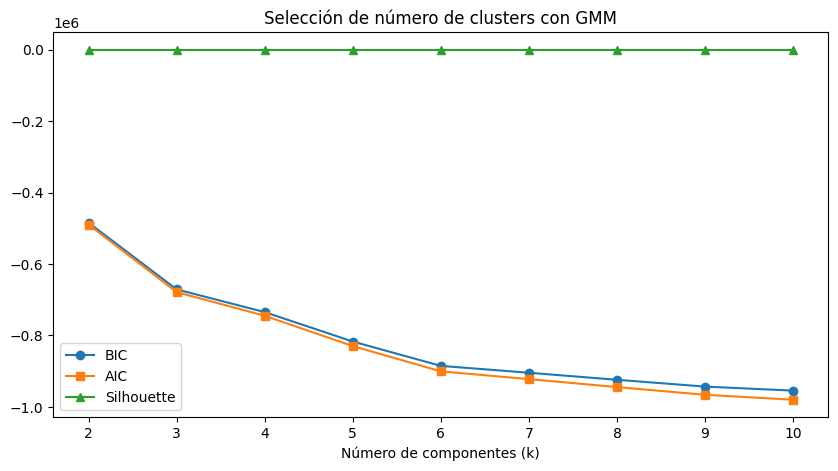

In [ ]:
from sklearn.mixture import GaussianMixture

# --- Evaluación de número de componentes ---
range_k = range(2, 11)
bics = []
aics = []
silhouettes_gmm = []

for k in range_k:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
    labels = gmm.fit_predict(df_num)

    bics.append(gmm.bic(df_num))
    aics.append(gmm.aic(df_num))
    silhouettes_gmm.append(silhouette_score(df_num, labels))

# --- Graficar BIC, AIC y Silhouette ---
plt.figure(figsize=(10,5))
plt.plot(range_k, bics, marker='o', label="BIC")
plt.plot(range_k, aics, marker='s', label="AIC")
plt.plot(range_k, silhouettes_gmm, marker='^', label="Silhouette")
plt.xlabel("Número de componentes (k)")
plt.title("Selección de número de clusters con GMM")
plt.legend()
plt.show()

In [ ]:
# --- Ajuste final con el mejor k ---
best_k = 3  # elige según BIC/Silhouette
gmm_final = GaussianMixture(n_components=best_k, random_state=42, n_init=10)
df_num['Cluster_GMM'] = gmm_final.fit_predict(df_num)

### Visualización (2 componentes principales)

In [ ]:
import plotly.express as px

# --- Reducción a 3D con PCA ---
pca_3d = PCA(n_components=3)
pca_data_3d = pca_3d.fit_transform(df_num.drop('Cluster_GMM', axis=1))

# --- Crear DataFrame con resultados PCA ---
df_pca = pd.DataFrame(pca_data_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster'] = df_num['Cluster_GMM'].astype(str)

# --- Gráfico 3D interactivo ---
fig = px.scatter_3d(
    df_pca,
    x='PC1', y='PC2', z='PC3',
    color='Cluster',
    symbol='Cluster',
    opacity=0.7,
    title='Clusters con GMM en 3D (PCA)'
)

fig.update_traces(marker=dict(size=5))
fig.show()

# Aprendizaje supervisado

Dado que contamos con la etiqueta "Expected life time", que representa la variable que deseamos predecir, decidimos aplicar métodos de **aprendizaje supervisado** para estimar la vida útil de los satélites.

In [ ]:
df_Scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3953 entries, 0 to 5884
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Eccentricity                                     3953 non-null   float64       
 1   Inclination (degrees)                            3953 non-null   float64       
 2   Launch_Mass_kg                                   3953 non-null   float64       
 3   Expected_Lifetime_yrs                            3953 non-null   float64       
 4   DECAY                                            630 non-null    datetime64[ns]
 5   PERIOD                                           3953 non-null   float64       
 6   Class_of_Orbit_Encoded                           3953 non-null   float64       
 7   Type_of_Orbit_Cislunar                           3953 non-null   float64       
 8   Type_of_Orbit_Deep Highly Eccentric        

In [ ]:
df_Scaled

,Eccentricity,Inclination (degrees),Launch_Mass_kg,Expected_Lifetime_yrs,DECAY,PERIOD,Class_of_Orbit_Encoded,Type_of_Orbit_Cislunar,Type_of_Orbit_Deep Highly Eccentric,Type_of_Orbit_Elliptical,...,Type_of_Orbit_Sun-Synchronous near polar,Type_of_Orbit_None,OBJECT_TYPE_PAYLOAD,Purpose_Grouped_Communications,Purpose_Grouped_Earth Observation,Purpose_Grouped_Navigation/Regional Positioning,Purpose_Grouped_Technology Development,anio_DtOfLaunch,mes_DtOfLaunch,dia_DtOfLaunch
0,-0.059042,0.257322,0.012071,-1.394985,NaT,0.021291,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.918367,1.000000,0.333333
2,-0.059484,0.679568,0.011206,-0.977854,2024-09-01,0.020905,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.877551,0.454545,0.733333
4,-0.068851,0.000558,0.324007,2.637283,NaT,0.085819,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.816327,0.090909,0.166667
5,-0.070161,0.000000,0.099995,2.637283,NaT,0.085820,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.857143,0.454545,0.466667
6,-0.068852,0.000697,0.109885,2.637283,NaT,0.085819,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.836735,0.181818,0.033333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5865,-0.068851,0.000418,0.238457,2.637283,NaT,0.085818,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.918367,0.181818,0.333333
5866,-0.069201,0.000209,0.270600,2.637283,NaT,0.085818,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.979592,0.272727,0.466667
5882,-0.064992,0.686890,0.142028,-0.143591,NaT,0.021525,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.918367,0.727273,0.433333
5883,-0.068018,0.679916,0.142028,-0.421679,NaT,0.021166,2.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.775510,0.000000,0.266667


Para poder aplicar los modelos Decision Tree y Random Forest, es necesario transformar la variable DECAY, que tiene tipo datetime64[ns], a valores numéricos (float64).

In [ ]:
# Copia del DataFrame original
df_proc = df_Scaled.copy()

# Asegurar que DECAY sea tipo datetime
df_proc["DECAY"] = pd.to_datetime(df_proc["DECAY"], errors="coerce")

# Crear nuevas columnas a partir de DECAY
df_proc["DECAY_year"] = df_proc["DECAY"].dt.year
df_proc["DECAY_month"] = df_proc["DECAY"].dt.month
df_proc["DECAY_day"] = df_proc["DECAY"].dt.day
df_proc["DECAY_age_days"] = (pd.to_datetime("today") - df_proc["DECAY"]).dt.days




In [ ]:
df_proc_validation = validationData.copy()

# Asegurar que DECAY sea tipo datetime
df_proc_validation["DECAY"] = pd.to_datetime(df_proc_validation["DECAY"], errors="coerce")

# Crear nuevas columnas a partir de DECAY
df_proc_validation["DECAY_year"] = df_proc_validation["DECAY"].dt.year
df_proc_validation["DECAY_month"] = df_proc_validation["DECAY"].dt.month
df_proc_validation["DECAY_day"] = df_proc_validation["DECAY"].dt.day
df_proc_validation["DECAY_age_days"] = (pd.to_datetime("today") - df_proc_validation["DECAY"]).dt.days

In [ ]:
df_proc_validation.shape

(1931, 30)

In [ ]:
# Eliminar la columna original DECAY
df_proc.drop(columns=["DECAY"], inplace=True)

# Redefinir X e y
X = df_proc.drop(columns=["Expected_Lifetime_yrs"])
y = df_proc["Expected_Lifetime_yrs"]

print("Columnas creadas a partir de DECAY:", ["DECAY_year", "DECAY_month", "DECAY_day", "DECAY_age_days"])
print("Shape final de X:", X.shape)

Columnas creadas a partir de DECAY: ['DECAY_year', 'DECAY_month', 'DECAY_day', 'DECAY_age_days']
Shape final de X: (3953, 28)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Desicion Tree model - sin PCA**



In [ ]:
# Crear y entrenar modelo Decision Tree
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Predicciones
y_pred_dt = dt_model.predict(X_test)

# Métricas
print("Decision Tree Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2:", r2_score(y_test, y_pred_dt))

Decision Tree Regressor
MAE: 0.08094770906696692
RMSE: 0.3780410847143301
R2: 0.8862311221516731


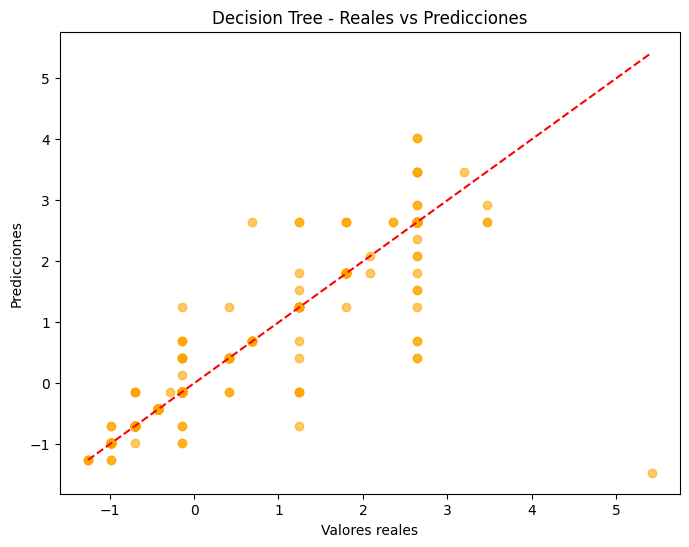

In [ ]:
# Gráfico valores reales vs predicciones
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_dt, alpha=0.6, color="orange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Decision Tree - Reales vs Predicciones")
plt.show()

En el grafico podemos ver que la mayoria de las predicciones estan alejadas de la recta lo cual indica que no es el mejor modelo.

# **Random Forest model - sin PCA**

In [ ]:
# Crear y entrenar modelo Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,  # cantidad de árboles
    random_state=42,
    n_jobs=-1,         # usa todos los núcleos disponibles
    oob_score=True     # permite calcular el OOB Score
)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Métricas
print("Random Forest Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

# OOB Score
print("OOB Score:", rf_model.oob_score_)

Random Forest Regressor
MAE: 0.07995805520801677
RMSE: 0.31247437834228226
R2: 0.9222725717261074
OOB Score: 0.9172177472173477


In [ ]:
X_validation_rf = df_proc_validation.drop(columns=["Expected_Lifetime_yrs", "DECAY"])
y_validation_rf = df_proc_validation["Expected_Lifetime_yrs"]

In [ ]:
y_validation_rf = rf_model.predict(X_validation_rf)

In [ ]:
# print("Random Forest Regressor")
# print("MAE:", mean_absolute_error(y_test, y_validation_rf))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, y_validation_rf)))
# print("R2:", r2_score(y_test, y_validation_rf))


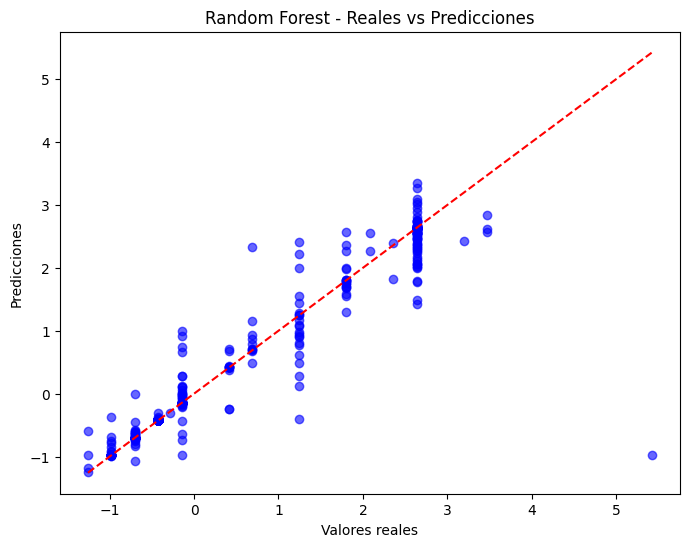

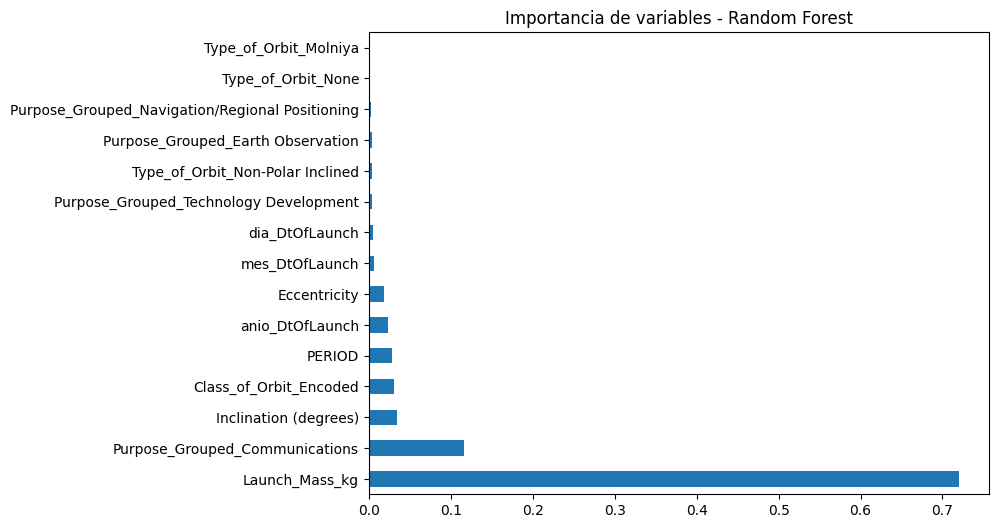

In [ ]:
# Gráfico reales vs predicciones
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Random Forest - Reales vs Predicciones")
plt.show()

# Importancia de variables
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.nlargest(15).plot(kind="barh", figsize=(8,6))
plt.title("Importancia de variables - Random Forest")
plt.show()

En este grafico lo que notamos es que nos demuestra contrario a nuestras creencia la cual era que la varible mas usada o con mayor peso iba a ser el purpose_grouped_Communications y aca muestra que tiene el mayor peso la variable Launch_mass_kg'.


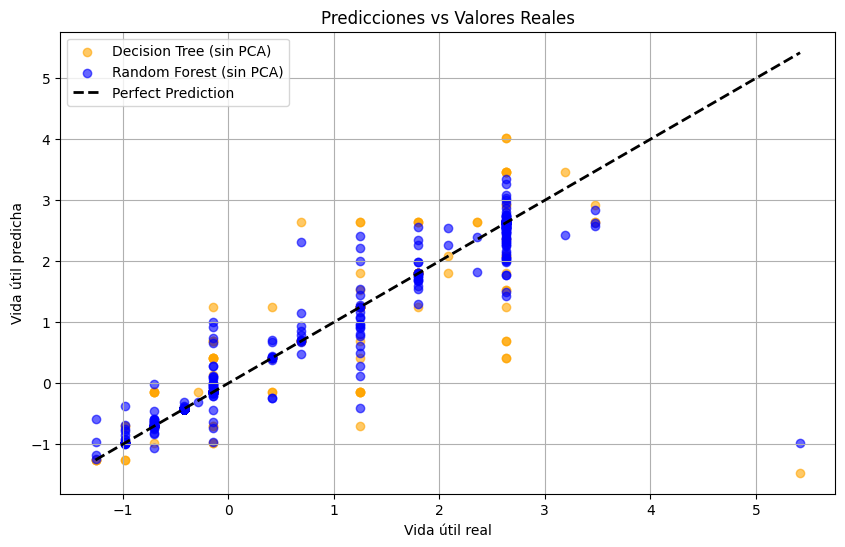

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Valores reales
plt.scatter(y_test, y_pred_dt, color='orange', alpha=0.6, label='Decision Tree (sin PCA)')
plt.scatter(y_test, y_pred_rf, color='blue', alpha=0.6, label='Random Forest (sin PCA)')

# Línea de referencia: predicción perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

plt.xlabel("Vida útil real")
plt.ylabel("Vida útil predicha")
plt.title("Predicciones vs Valores Reales")
plt.legend()
plt.grid(True)
plt.show()

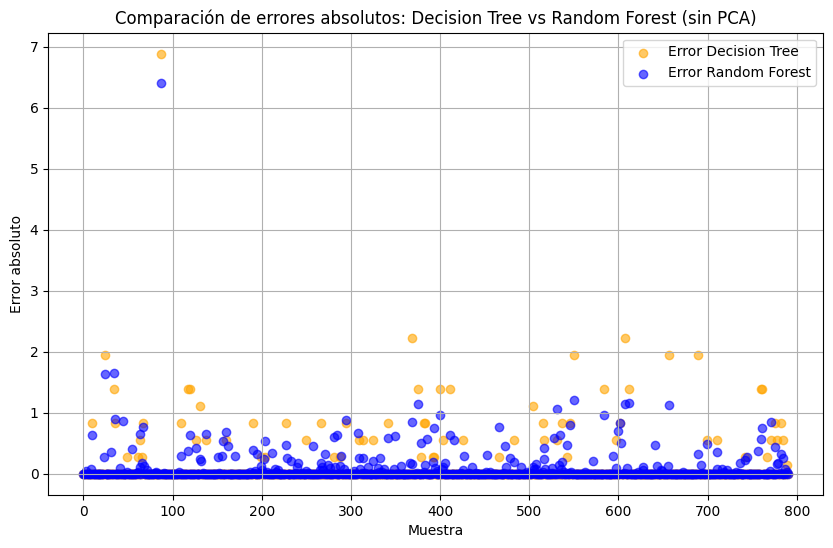

In [ ]:
# Calcular errores absolutos
error_dt = np.abs(y_test - y_pred_dt)   # errores Decision Tree
error_rf = np.abs(y_test - y_pred_rf)   # errores Random Forest

plt.figure(figsize=(10,6))

# Gráfico de dispersión
plt.scatter(range(len(y_test)), error_dt, color='orange', alpha=0.6, label='Error Decision Tree')
plt.scatter(range(len(y_test)), error_rf, color='blue', alpha=0.6, label='Error Random Forest')

plt.xlabel("Muestra")
plt.ylabel("Error absoluto")
plt.title("Comparación de errores absolutos: Decision Tree vs Random Forest (sin PCA)")
plt.legend()
plt.grid(True)
plt.show()

Ahora intentamos afinar hiperparámetros, para mejorar los ajustes para Random Forest model

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint

# Random Forest base
rf = RandomForestRegressor(random_state=42, oob_score=True, n_jobs=-1)

# Definir distribuciones de hiperparámetros
param_dist = {
    'n_estimators': randint(100, 500),       # número de árboles entre 100 y 500
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 11),     # mínimo de muestras para dividir
    'min_samples_leaf': randint(1, 5),       # mínimo de muestras en la hoja
    'max_features': ['auto', 'sqrt', 'log2']
}

# Configurar Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,         # número de combinaciones aleatorias a probar
    cv=5,
    n_jobs=-1,
    scoring='r2',
    verbose=2,
    random_state=42
)

# Entrenar Randomized Search
random_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros:", random_search.best_params_)
print("Mejor R² en validación:", random_search.best_score_)

# Entrenar modelo final con mejores parámetros y calcular OOB Score
best_rf_random = random_search.best_estimator_
best_rf_random.fit(X_train, y_train)
print("OOB Score del mejor modelo:", best_rf_random.oob_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning:


80 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils

Mejores hiperparámetros: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 443}
Mejor R² en validación: 0.9171851630805309
OOB Score del mejor modelo: 0.9190692350044127


Comparamos el metodo, antes y despues de ajustar hiperparámetros:

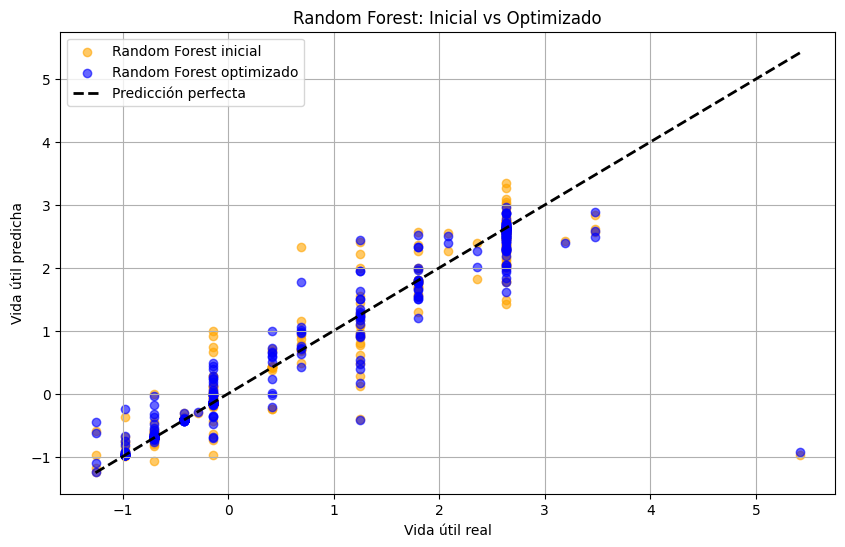

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Valores reales
plt.scatter(y_test, y_pred_rf, color='orange', alpha=0.6, label='Random Forest inicial')
plt.scatter(y_test, best_rf_random.predict(X_test), color='blue', alpha=0.6, label='Random Forest optimizado')

# Línea de referencia: predicción perfecta
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Predicción perfecta')

plt.xlabel("Vida útil real")
plt.ylabel("Vida útil predicha")
plt.title("Random Forest: Inicial vs Optimizado")
plt.legend()
plt.grid(True)
plt.show()

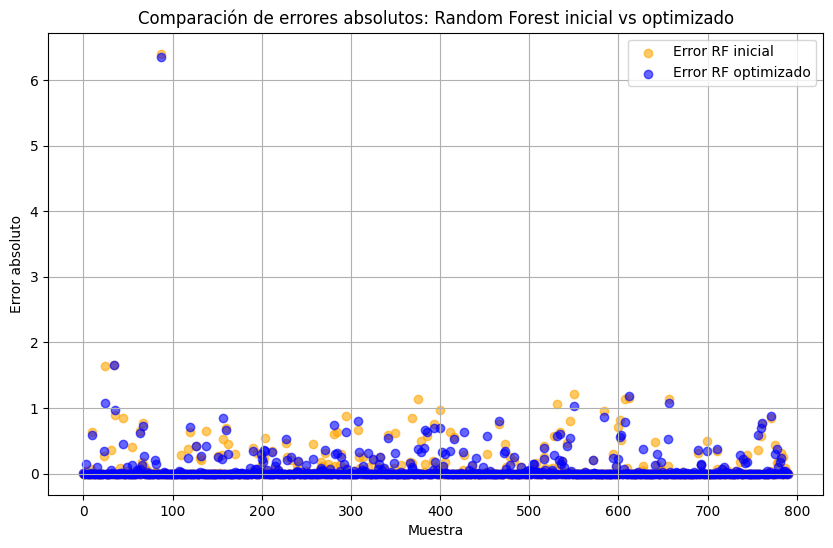

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calcular errores absolutos
error_inicial = np.abs(y_test - y_pred_rf)
error_optimizado = np.abs(y_test - best_rf_random.predict(X_test))

plt.figure(figsize=(10,6))

# Gráfico de dispersión
plt.scatter(range(len(y_test)), error_inicial, color='orange', alpha=0.6, label='Error RF inicial')
plt.scatter(range(len(y_test)), error_optimizado, color='blue', alpha=0.6, label='Error RF optimizado')

plt.xlabel("Muestra")
plt.ylabel("Error absoluto")
plt.title("Comparación de errores absolutos: Random Forest inicial vs optimizado")
plt.legend()
plt.grid(True)
plt.show()

# **Desicion Tree model - con PCA**

In [ ]:
# Entrenar Decision Tree con los datos transformados por PCA
dt_pca_model = DecisionTreeRegressor(random_state=42)
dt_pca_model.fit(X_train, y_train)

# Predicciones
y_pred_dt_pca = dt_pca_model.predict(X_test)

# Métricas
print("Decision Tree Regressor con PCA")
print("MAE:", mean_absolute_error(y_test, y_pred_dt_pca))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt_pca)))
print("R2:", r2_score(y_test, y_pred_dt_pca))

Decision Tree Regressor con PCA
MAE: 0.08094770906696692
RMSE: 0.3780410847143301
R2: 0.8862311221516731


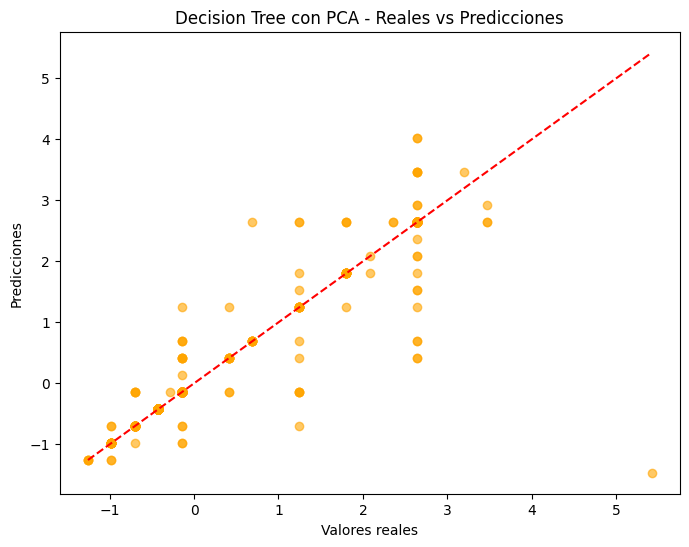

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_dt_pca, alpha=0.6, color="orange", label='Decision Tree + PCA')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Decision Tree con PCA - Reales vs Predicciones")
plt.show()

En el grafico podemos ver que la mayoria de las predicciones estan alejadas de la recta lo cual indica quesigue sin ser el mejor modelo.

# **Random Forest model - con PCA**

In [ ]:
# PCA (nos quedamos con componentes que explican el 75% de la varianza)
pca = PCA(n_components=0.75)
pca_result = pca.fit_transform(df_Scaled[tp])

# Convertimos a DataFrame
pca_df = pd.DataFrame(
    pca_result,
    columns=[f'PC{i+1}' for i in range(pca_result.shape[1])],
    index=df_Scaled.index
)

# Separamos en train/test
X_train, X_test, y_train, y_test = train_test_split(
    pca_df, y, test_size=0.2, random_state=42
)

# Random Forest con PCA
rf_model_pca = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_model_pca.fit(X_train, y_train)

# Predicciones
y_pred_rf_pca = rf_model_pca.predict(X_test)

# Métricas
print("Random Forest Regressor con PCA")
print("MAE:", mean_absolute_error(y_test, y_pred_rf_pca))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_pca)))
print("R2:", r2_score(y_test, y_pred_rf_pca))

Random Forest Regressor con PCA
MAE: 0.00380744273266654
RMSE: 0.03874825687467618
R2: 0.9988047746008695


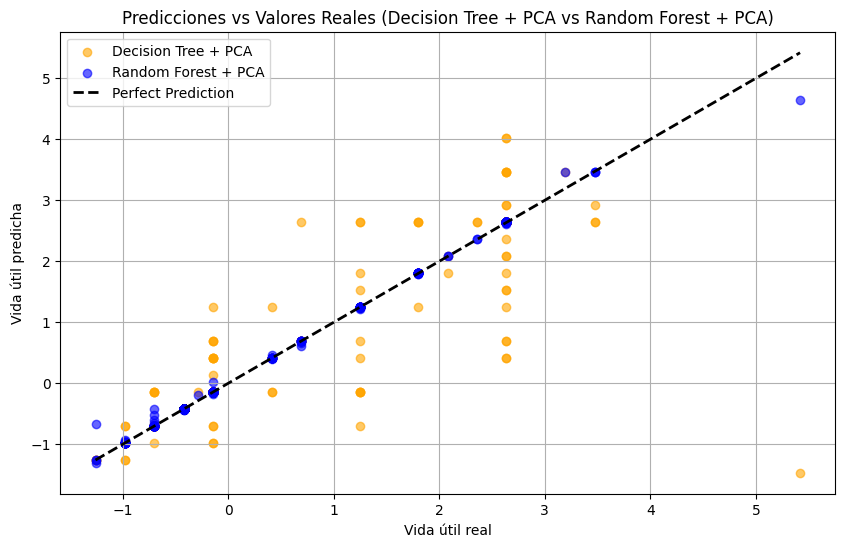

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Valores reales vs Decision Tree
plt.scatter(y_test, y_pred_dt_pca, color='orange', alpha=0.6, label='Decision Tree + PCA')

# Valores reales vs Random Forest con PCA
plt.scatter(y_test, y_pred_rf_pca, color='blue', alpha=0.6, label='Random Forest + PCA')

# Línea de referencia: predicción perfecta
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'k--', lw=2, label='Perfect Prediction'
)

plt.xlabel("Vida útil real")
plt.ylabel("Vida útil predicha")
plt.title("Predicciones vs Valores Reales (Decision Tree + PCA vs Random Forest + PCA)")
plt.legend()
plt.grid(True)
plt.show()

En este gráfico podemos ver que, al aplicar los modelos sobre los componentes principales obtenidos con PCA, el ajuste presenta una mejora respecto al caso sin PCA.

# **Gradient Boosting Regressor**

In [ ]:
df_Scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3953 entries, 0 to 5884
Data columns (total 26 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Eccentricity                                     3953 non-null   float64       
 1   Inclination (degrees)                            3953 non-null   float64       
 2   Launch_Mass_kg                                   3953 non-null   float64       
 3   Expected_Lifetime_yrs                            3953 non-null   float64       
 4   DECAY                                            630 non-null    datetime64[ns]
 5   PERIOD                                           3953 non-null   float64       
 6   Class_of_Orbit_Encoded                           3953 non-null   float64       
 7   Type_of_Orbit_Cislunar                           3953 non-null   float64       
 8   Type_of_Orbit_Deep Highly Eccentric        

In [ ]:
def preparar_features_SGD(subset):
    X = subset.drop(columns=["Expected_Lifetime_yrs", "Class_of_Orbit_Encoded", "DECAY"])
    y = subset["Expected_Lifetime_yrs"].copy()

    X = X.select_dtypes(include=[np.number])

    return X, y

In [ ]:
x_train_SGD, y_train_SGD = preparar_features_SGD(df_Scaled)

In [ ]:
from sklearn.linear_model import SGDRegressor

sgd = SGDRegressor(max_iter=100, random_state=5)
sgd.fit(x_train_SGD, y_train_SGD)
sgd.score(x_train_SGD, y_train_SGD)

0.6374527990476475

In [ ]:
x_validation, y_validation = preparar_features_SGD(validationData)

predicted = sgd.predict(x_validation)

In [ ]:
predicted.shape


(1931,)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Suponiendo que tienes las predicciones y los valores reales:
y_true = y_validation  # o el conjunto de validación correspondiente
y_pred = predicted  # o el conjunto de validación correspondiente

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

MAE: 0.272
RMSE: 0.576
R2: 0.438


#Conclusion

Se probaron 3 modelos de aprendizaje supervisado:
  1- DecisionTree
  2-RandomForest
  3-SGDregresor,
A RandomForest y DesicionTree los entrenamos con PCA y sin PCA para comparar los resultados. Luego usamos las metricas MAE, RMSE y R2; revisando los resultados el mejor modelo de entrenamiento fue RandomForest.

Vimos que SGDregreso al principio nos arrojo buenas metricas pero al usar el dataset de validacion el resultado empeoro.